In [ ]:
!pip install opencv-python scikit-learn

In [ ]:
# Cell 1: Imports, Setup, Dataset Loading

import os
import cv2
import copy
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from IPython.display import display

import torchvision.datasets as datasets
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------------------------------------------------
# Directory Setup
# Supports both Google Colab and local VS Code
# ---------------------------------------------------------
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

    print("Running in Google Colab")

    DATA_DIR = Path("/content/data")
    ROOT_DIR = Path("/content/drive/MyDrive/Digital_image_processing_project")

else:
    print("Running locally / VS Code")

    current_dir = Path.cwd()
    ROOT_DIR = current_dir.parent if current_dir.name == "notebooks" else current_dir
    DATA_DIR = ROOT_DIR / "data"

RESULTS_DIR = ROOT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = ROOT_DIR / "models"

for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)
print("MODELS_DIR:", MODELS_DIR)

# ---------------------------------------------------------
# Device
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# Load PASCAL VOC 2012
# Train is used for fine-tuning
# Val is used for evaluation
# ---------------------------------------------------------
voc_root = DATA_DIR / "VOCdevkit" / "VOC2012"
download_voc = not voc_root.exists()

print("VOC dataset exists:", voc_root.exists())
print("download_voc:", download_voc)

voc_train = datasets.VOCDetection(
    root=str(DATA_DIR),
    year="2012",
    image_set="train",
    download=download_voc
)

voc_val = datasets.VOCDetection(
    root=str(DATA_DIR),
    year="2012",
    image_set="val",
    download=False
)

print(f"Loaded VOC train set: {len(voc_train)} images")
print(f"Loaded VOC val set: {len(voc_val)} images")

# ---------------------------------------------------------
# VOC classes
# ---------------------------------------------------------
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

VOC_CLASS_TO_INDEX = {
    class_name: idx for idx, class_name in enumerate(VOC_CLASSES)
}

print("Cell 1 completed successfully.")

Mounted at /content/drive
Running in Google Colab
ROOT_DIR: /content/drive/MyDrive/Digital_image_processing_project
DATA_DIR: /content/data
RESULTS_DIR: /content/drive/MyDrive/Digital_image_processing_project/results
FIGURES_DIR: /content/drive/MyDrive/Digital_image_processing_project/results/figures
TABLES_DIR: /content/drive/MyDrive/Digital_image_processing_project/results/tables
MODELS_DIR: /content/drive/MyDrive/Digital_image_processing_project/models
Using device: cuda
VOC dataset exists: False
download_voc: True


100%|██████████| 2.00G/2.00G [01:12<00:00, 27.5MB/s]


Loaded VOC train set: 5717 images
Loaded VOC val set: 5823 images
Cell 1 completed successfully.


In [ ]:
# Cell 2: Distortion Functions + Label Functions

# ---------------------------------------------------------
# 1. Convert PASCAL VOC annotations to multi-label vector
# ---------------------------------------------------------
def target_to_multilabel(target):
    """
    Convert a PASCAL VOC annotation into a 20-dimensional
    multi-label vector.

    Example:
    If an image contains a dog and a person, the entries
    corresponding to 'dog' and 'person' are set to 1.
    """
    y = np.zeros(len(VOC_CLASSES), dtype=np.float32)

    objects = target["annotation"].get("object", [])

    if isinstance(objects, dict):
        objects = [objects]

    for obj in objects:
        class_name = obj["name"]

        if class_name in VOC_CLASS_TO_INDEX:
            class_index = VOC_CLASS_TO_INDEX[class_name]
            y[class_index] = 1.0

    return y


# ---------------------------------------------------------
# 2. Salt & Pepper Noise
# ---------------------------------------------------------
def add_salt_pepper_noise(
    image,
    amount,
    salt_vs_pepper=0.5,
    seed=42
):
    """
    Add salt-and-pepper impulse noise to an RGB image.

    Parameters:
        image:
            Input RGB image as a NumPy array.

        amount:
            Fraction of image pixels affected by the noise.

        salt_vs_pepper:
            Fraction of noisy pixels that become white.
            The remaining noisy pixels become black.

        seed:
            Random seed for reproducibility.
    """
    rng = np.random.default_rng(seed)

    noisy = image.copy()
    height, width, _ = noisy.shape

    num_pixels = int(amount * height * width)

    # Salt pixels
    num_salt = int(num_pixels * salt_vs_pepper)

    salt_y = rng.integers(0, height, num_salt)
    salt_x = rng.integers(0, width, num_salt)

    noisy[salt_y, salt_x] = 255

    # Pepper pixels
    num_pepper = num_pixels - num_salt

    pepper_y = rng.integers(0, height, num_pepper)
    pepper_x = rng.integers(0, width, num_pepper)

    noisy[pepper_y, pepper_x] = 0

    return noisy


# ---------------------------------------------------------
# 3. Overexposure
# ---------------------------------------------------------
def add_overexposure(image, factor, bias):
    """
    Simulate overexposure using multiplication and additive bias.

    distorted = clean * factor + bias
    """
    exposed = image.astype(np.float32) * factor + bias

    return np.clip(
        exposed,
        0,
        255
    ).astype(np.uint8)


# ---------------------------------------------------------
# 4. Motion Blur
# ---------------------------------------------------------
def add_motion_blur(image, kernel_size):
    """
    Apply horizontal motion blur using a linear kernel.
    """
    # The motion-blur kernel must have an odd size.
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = np.zeros(
        (kernel_size, kernel_size),
        dtype=np.float32
    )

    kernel[kernel_size // 2, :] = 1.0 / kernel_size

    blurred = cv2.filter2D(
        image,
        -1,
        kernel
    )

    return blurred


# ---------------------------------------------------------
# 5. Unified Distortion Function
# ---------------------------------------------------------
def apply_distortion(image, config, seed=42):
    """
    Apply a distortion according to a configuration dictionary.

    Expected configuration format:
    {
        "name": "...",
        "type": "salt_pepper" / "overexposure" /
                "motion_blur" / "clean",
        "severity_level": ...,
        "severity_label": "...",
        "params": {...}
    }
    """
    distortion_type = config["type"]
    params = config["params"]

    if distortion_type == "clean":
        return image.copy()

    if distortion_type == "salt_pepper":
        return add_salt_pepper_noise(
            image,
            seed=seed,
            **params
        )

    if distortion_type == "overexposure":
        return add_overexposure(
            image,
            **params
        )

    if distortion_type == "motion_blur":
        return add_motion_blur(
            image,
            **params
        )

    raise ValueError(
        f"Unknown distortion type: {distortion_type}"
    )


# ---------------------------------------------------------
# 6. Signal-to-Noise Ratio
# ---------------------------------------------------------
def compute_snr(clean, distorted):
    """
    Compute SNR between the clean and distorted image.

    Higher SNR means the distorted image is more similar
    to the clean image.
    """
    clean = clean.astype(np.float32)
    distorted = distorted.astype(np.float32)

    noise_power = np.mean(
        (clean - distorted) ** 2
    )

    signal_power = np.mean(
        clean ** 2
    )

    if noise_power == 0:
        return np.inf

    return float(
        10 * np.log10(signal_power / noise_power)
    )


# ---------------------------------------------------------
# 7. Six Distortion Levels Used in Part 2
# ---------------------------------------------------------
DISTORTION_LEVELS = {
    "salt_pepper": [
        {
            "level": 1,
            "params": {"amount": 0.005}
        },
        {
            "level": 2,
            "params": {"amount": 0.010}
        },
        {
            "level": 3,
            "params": {"amount": 0.030}
        },
        {
            "level": 4,
            "params": {"amount": 0.070}
        },
        {
            "level": 5,
            "params": {"amount": 0.150}
        },
        {
            "level": 6,
            "params": {"amount": 0.300}
        },
    ],

    "overexposure": [
        {
            "level": 1,
            "params": {
                "factor": 1.10,
                "bias": 10
            }
        },
        {
            "level": 2,
            "params": {
                "factor": 1.30,
                "bias": 20
            }
        },
        {
            "level": 3,
            "params": {
                "factor": 1.60,
                "bias": 35
            }
        },
        {
            "level": 4,
            "params": {
                "factor": 2.00,
                "bias": 50
            }
        },
        {
            "level": 5,
            "params": {
                "factor": 2.50,
                "bias": 75
            }
        },
        {
            "level": 6,
            "params": {
                "factor": 3.20,
                "bias": 100
            }
        },
    ],

    "motion_blur": [
        {
            "level": 1,
            "params": {"kernel_size": 3}
        },
        {
            "level": 2,
            "params": {"kernel_size": 7}
        },
        {
            "level": 3,
            "params": {"kernel_size": 11}
        },
        {
            "level": 4,
            "params": {"kernel_size": 15}
        },
        {
            "level": 5,
            "params": {"kernel_size": 25}
        },
        {
            "level": 6,
            "params": {"kernel_size": 41}
        },
    ],
}


# ---------------------------------------------------------
# 8. Standard Evaluation Conditions
# Clean + 6 levels for each of the 3 distortions
# ---------------------------------------------------------
DISTORTION_CONFIGS = [
    {
        "name": "clean",
        "type": "clean",
        "severity_level": 0,
        "severity_label": "Clean",
        "params": {}
    }
]

for distortion_type, levels in DISTORTION_LEVELS.items():
    for level_config in levels:
        level = level_config["level"]

        DISTORTION_CONFIGS.append({
            "name": f"{distortion_type}_L{level}",
            "type": distortion_type,
            "severity_level": level,
            "severity_label": f"L{level}",
            "params": level_config["params"]
        })


# ---------------------------------------------------------
# 9. Training Conditions
# The fine-tuning model is trained on distorted images only.
# ---------------------------------------------------------
TRAIN_DISTORTION_CONFIGS = [
    config
    for config in DISTORTION_CONFIGS
    if config["type"] != "clean"
]


# ---------------------------------------------------------
# 10. Exact Distortion Settings Used in Part 3 Restoration
#
# These configurations are stored separately so that the
# final comparison can use the exact settings already used
# by the restoration notebook without modifying Part 3.
# ---------------------------------------------------------
RESTORATION_REFERENCE_CONFIGS = [
    {
        "name": "salt_pepper_restoration_reference",
        "type": "salt_pepper",
        "severity_level": 4,
        "severity_label": "Restoration Reference",
        "params": {
            "amount": 0.07
        }
    },

    {
        "name": "overexposure_restoration_reference",
        "type": "overexposure",
        "severity_level": None,
        "severity_label": "Restoration Reference",
        "params": {
            "factor": 1.6,
            "bias": 30
        }
    },

    {
        "name": "motion_blur_restoration_reference",
        "type": "motion_blur",
        "severity_level": 4,
        "severity_label": "Restoration Reference",
        "params": {
            "kernel_size": 15
        }
    },
]


# ---------------------------------------------------------
# 11. Verification Output
# ---------------------------------------------------------
print(
    "Total standard evaluation conditions:",
    len(DISTORTION_CONFIGS)
)

print(
    "Training distortion conditions:",
    len(TRAIN_DISTORTION_CONFIGS)
)

print(
    "Restoration reference conditions:",
    len(RESTORATION_REFERENCE_CONFIGS)
)


print("\nStandard evaluation conditions:")

for config in DISTORTION_CONFIGS:
    print(
        config["name"],
        "| type:", config["type"],
        "| severity:", config["severity_label"],
        "| params:", config["params"]
    )


print("\nRestoration reference conditions:")

for config in RESTORATION_REFERENCE_CONFIGS:
    print(
        config["name"],
        "| type:", config["type"],
        "| params:", config["params"]
    )


print("\nCell 2 completed successfully.")

Total standard evaluation conditions: 19
Training distortion conditions: 18
Restoration reference conditions: 3

Standard evaluation conditions:
clean | type: clean | severity: Clean | params: {}
salt_pepper_L1 | type: salt_pepper | severity: L1 | params: {'amount': 0.005}
salt_pepper_L2 | type: salt_pepper | severity: L2 | params: {'amount': 0.01}
salt_pepper_L3 | type: salt_pepper | severity: L3 | params: {'amount': 0.03}
salt_pepper_L4 | type: salt_pepper | severity: L4 | params: {'amount': 0.07}
salt_pepper_L5 | type: salt_pepper | severity: L5 | params: {'amount': 0.15}
salt_pepper_L6 | type: salt_pepper | severity: L6 | params: {'amount': 0.3}
overexposure_L1 | type: overexposure | severity: L1 | params: {'factor': 1.1, 'bias': 10}
overexposure_L2 | type: overexposure | severity: L2 | params: {'factor': 1.3, 'bias': 20}
overexposure_L3 | type: overexposure | severity: L3 | params: {'factor': 1.6, 'bias': 35}
overexposure_L4 | type: overexposure | severity: L4 | params: {'factor':

In [ ]:
# Cell 3: Dataset Class for Fine-Tuning on Distorted Images

weights = ResNet50_Weights.DEFAULT
transform = weights.transforms()


class VOCDistortedClassificationDataset(Dataset):
    """
    Dataset for multi-label classification on distorted PASCAL VOC images.

    Supported modes
    ---------------

    mode="random":
        A random distortion type and severity level are selected whenever
        an image is loaded. This mode is used for training.

    mode="fixed_random":
        Each image receives one deterministic distortion configuration.
        The same image receives the same distortion in every epoch.
        This mode is used for validation during fine-tuning.

    mode="fixed":
        The same condition_config is applied to every image.
        This mode is used for evaluation on a particular distortion level.
    """

    def __init__(
        self,
        voc_dataset,
        mode="random",
        condition_config=None,
        max_samples=None,
        seed=42
    ):
        self.voc_dataset = voc_dataset
        self.mode = mode
        self.condition_config = condition_config
        self.seed = seed

        # Create a reproducible list of dataset indices.
        self.indices = list(range(len(voc_dataset)))

        index_rng = random.Random(seed)
        index_rng.shuffle(self.indices)

        if max_samples is not None:
            self.indices = self.indices[:max_samples]

        valid_modes = {
            "random",
            "fixed_random",
            "fixed"
        }

        if self.mode not in valid_modes:
            raise ValueError(
                "mode must be 'random', 'fixed_random', or 'fixed'."
            )

        if self.mode == "fixed" and self.condition_config is None:
            raise ValueError(
                "condition_config must be provided when mode='fixed'."
            )


    def __len__(self):
        return len(self.indices)


    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        # Load clean image and original PASCAL VOC annotation.
        img, target = self.voc_dataset[real_idx]

        clean_image = np.array(
            img.convert("RGB")
        ).copy()

        # -------------------------------------------------
        # Training mode
        # -------------------------------------------------
        if self.mode == "random":
            """
            During training, a random distortion condition is selected
            whenever the image is loaded.

            This means that the same clean image can appear with different
            distortions in different epochs.
            """
            config = random.choice(
                TRAIN_DISTORTION_CONFIGS
            )

            distorted_image = apply_distortion(
                clean_image,
                config,
                seed=self.seed + real_idx + idx
            )

        # -------------------------------------------------
        # Validation mode
        # -------------------------------------------------
        elif self.mode == "fixed_random":
            """
            Each validation image receives one deterministic distortion.

            The distortion is selected using a local random generator
            based on the dataset seed and the original image index.

            Therefore, the validation input remains identical in every
            epoch and validation loss can be compared reliably.
            """
            config_rng = random.Random(
                self.seed + real_idx
            )

            config = config_rng.choice(
                TRAIN_DISTORTION_CONFIGS
            )

            distorted_image = apply_distortion(
                clean_image,
                config,
                seed=self.seed + real_idx
            )

        # -------------------------------------------------
        # Fixed-condition evaluation mode
        # -------------------------------------------------
        elif self.mode == "fixed":
            """
            Apply one explicitly supplied distortion condition.

            This is used when evaluating every model separately on:
            clean, salt_pepper_L1, salt_pepper_L2, and so on.
            """
            config = self.condition_config

            distorted_image = apply_distortion(
                clean_image,
                config,
                seed=self.seed + real_idx
            )

        # -------------------------------------------------
        # Multi-label target
        # -------------------------------------------------
        label = target_to_multilabel(target)

        # -------------------------------------------------
        # SNR
        # -------------------------------------------------
        snr = compute_snr(
            clean_image,
            distorted_image
        )

        # -------------------------------------------------
        # ResNet50 preprocessing
        # -------------------------------------------------
        distorted_pil = Image.fromarray(
            distorted_image.astype(np.uint8)
        ).convert("RGB")

        image_tensor = transform(
            distorted_pil
        )

        label_tensor = torch.tensor(
            label,
            dtype=torch.float32
        )

        snr_tensor = torch.tensor(
            snr,
            dtype=torch.float32
        )

        return (
            image_tensor,
            label_tensor,
            snr_tensor
        )


# ---------------------------------------------------------
# Basic verification
# ---------------------------------------------------------
print("Dataset class loaded successfully.")
print("Supported modes:")
print("- random       : training with changing distortions")
print("- fixed_random : validation with fixed distortions")
print("- fixed        : evaluation on one specified condition")
print("Cell 3 completed successfully.")

Dataset class loaded successfully.
Supported modes:
- random       : training with changing distortions
- fixed_random : validation with fixed distortions
- fixed        : evaluation on one specified condition
Cell 3 completed successfully.


In [ ]:
# Cell 4: Load the Clean-Trained Baseline Model
#
# This cell:
# 1. Defines the ResNet50 multi-label architecture
# 2. Loads the clean-trained checkpoint
# 3. Creates the unchanged baseline model
#
# The two controlled fine-tuning models will be created
# separately in Cell 5.

# ---------------------------------------------------------
# 1. Runtime Parameters
# ---------------------------------------------------------
BATCH_SIZE = 32 if device.type == "cuda" else 4
NUM_WORKERS = 2 if device.type == "cuda" else 0

print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_WORKERS:", NUM_WORKERS)


# ---------------------------------------------------------
# 2. Build ResNet50 Multi-Label Architecture
# ---------------------------------------------------------
def build_resnet50_multilabel():
    """
    Build the same ResNet50 architecture used in the
    clean-baseline notebook.

    The checkpoint weights are loaded separately.
    """
    model = resnet50(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        len(VOC_CLASSES)
    )

    return model


# ---------------------------------------------------------
# 3. Locate the Clean-Trained Checkpoint
# ---------------------------------------------------------
clean_model_path = (
    MODELS_DIR /
    "resnet50_multilabel_clean.pth"
)

print("\nLooking for clean-trained model at:")
print(clean_model_path)
print("Model exists:", clean_model_path.exists())

if not clean_model_path.exists():
    raise FileNotFoundError(
        f"Missing clean-trained model:\n"
        f"{clean_model_path}\n\n"
        "Run the clean-baseline notebook first or "
        "verify the checkpoint path."
    )


# ---------------------------------------------------------
# 4. Helper Function
#
# Every controlled model must start from exactly the same
# clean-trained checkpoint.
# ---------------------------------------------------------
def load_clean_checkpoint_model():
    model = build_resnet50_multilabel()

    state_dict = torch.load(
        clean_model_path,
        map_location=device
    )

    model.load_state_dict(
        state_dict
    )

    return model.to(device)


# ---------------------------------------------------------
# 5. Original Clean-Trained Baseline
#
# This model remains unchanged.
# It is used as the original baseline during evaluation.
# ---------------------------------------------------------
base_model = load_clean_checkpoint_model()

base_model.eval()

for parameter in base_model.parameters():
    parameter.requires_grad = False

print(
    "Original clean-trained baseline model "
    "loaded successfully."
)


# ---------------------------------------------------------
# 6. Verify Baseline Parameters
# ---------------------------------------------------------
total_parameters = sum(
    parameter.numel()
    for parameter in base_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in base_model.parameters()
    if parameter.requires_grad
)

print("\nBaseline parameter summary:")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

assert trainable_parameters == 0, (
    "The original baseline model must remain frozen."
)


# ---------------------------------------------------------
# 7. Clean Configuration
#
# This configuration will be used later for the clean
# fine-tuning control dataset.
# ---------------------------------------------------------
CLEAN_CONFIG = next(
    config
    for config in DISTORTION_CONFIGS
    if config["type"] == "clean"
)

print("\nClean control configuration:")
print(CLEAN_CONFIG)

print("\nCell 4 completed successfully.")

BATCH_SIZE: 4
NUM_WORKERS: 0

Looking for clean-trained model at:
/content/drive/MyDrive/Digital_image_processing_project/models/resnet50_multilabel_clean.pth
Model exists: True
Original clean-trained baseline model loaded successfully.

Baseline parameter summary:
Total parameters: 23,549,012
Trainable parameters: 0

Clean control configuration:
{'name': 'clean', 'type': 'clean', 'severity_level': 0, 'severity_label': 'Clean', 'params': {}}

Cell 4 completed successfully.


In [ ]:
# Cell 5: Controlled Fine-Tuning Experiment
#
# Two models start from the exact same clean-trained checkpoint:
#
# 1. Clean Control Model
#    Additional fine-tuning on clean images.
#
# 2. Distortion-Aware Model
#    Additional fine-tuning on distorted versions
#    of the same original images.
#
# Both models use:
# - The same image indices
# - The same number of samples
# - The same number of epochs
# - The same trainable layers
# - The same optimizer and learning rates
# - The same batch order
# - The same validation images
#
# The only intentional difference is:
# clean input versus distorted input.

print("Starting controlled fine-tuning experiment...")


# ---------------------------------------------------------
# 1. Reproducibility
# ---------------------------------------------------------
def reset_random_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def seed_worker(worker_id):
    """
    Set deterministic seeds inside each DataLoader worker.
    """
    worker_seed = torch.initial_seed() % (2 ** 32)

    random.seed(worker_seed)
    np.random.seed(worker_seed)


reset_random_seeds(SEED)


# ---------------------------------------------------------
# 2. Controlled Experiment Parameters
#
# These parameters are identical for both models.
# ---------------------------------------------------------
CONTROLLED_TRAIN_SAMPLES = min(
    4500,
    len(voc_train)
)

CONTROLLED_VAL_SAMPLES = min(
    800,
    len(voc_val)
)

CONTROLLED_EPOCHS = 8

print("\nControlled training configuration:")
print(
    "Training samples per model:",
    CONTROLLED_TRAIN_SAMPLES
)
print(
    "Validation images:",
    CONTROLLED_VAL_SAMPLES
)
print(
    "Epochs per model:",
    CONTROLLED_EPOCHS
)
print("Batch size:", BATCH_SIZE)
print("Device:", device)


# ---------------------------------------------------------
# 3. Distortion Sampling Distribution
#
# Severe levels appear more frequently during distorted
# fine-tuning:
#
# L1: 1 repetition
# L2: 1 repetition
# L3: 2 repetitions
# L4: 3 repetitions
# L5: 4 repetitions
# L6: 5 repetitions
# ---------------------------------------------------------
SEVERITY_REPEATS = {
    1: 1,
    2: 1,
    3: 2,
    4: 3,
    5: 4,
    6: 5
}

WEIGHTED_DISTORTION_CONFIGS = []

for config in DISTORTION_CONFIGS:

    if config["type"] == "clean":
        continue

    severity = int(
        config["severity_level"]
    )

    repetitions = SEVERITY_REPEATS[
        severity
    ]

    WEIGHTED_DISTORTION_CONFIGS.extend(
        [config] * repetitions
    )


# VOCDistortedClassificationDataset reads this list
# in random and fixed_random modes.
TRAIN_DISTORTION_CONFIGS = list(
    WEIGHTED_DISTORTION_CONFIGS
)

print(
    "\nWeighted distortion configurations:",
    len(TRAIN_DISTORTION_CONFIGS)
)

for severity in range(1, 7):

    severity_count = sum(
        1
        for config in TRAIN_DISTORTION_CONFIGS
        if config["severity_level"] == severity
    )

    print(
        f"L{severity} weighted entries:",
        severity_count
    )


# ---------------------------------------------------------
# 4. Clean-Control Training Dataset
#
# The images remain clean.
# ---------------------------------------------------------
clean_control_train_dataset = (
    VOCDistortedClassificationDataset(
        voc_dataset=voc_train,
        mode="fixed",
        condition_config=CLEAN_CONFIG,
        max_samples=CONTROLLED_TRAIN_SAMPLES,
        seed=SEED + 400
    )
)


# ---------------------------------------------------------
# 5. Distortion-Aware Training Dataset
#
# Uses the same original image indices, but applies a
# randomly selected distortion whenever an image is loaded.
# ---------------------------------------------------------
distorted_train_dataset = (
    VOCDistortedClassificationDataset(
        voc_dataset=voc_train,
        mode="random",
        max_samples=CONTROLLED_TRAIN_SAMPLES,
        seed=SEED + 400
    )
)


# Verify that both models train on the same original images.
assert (
    clean_control_train_dataset.indices ==
    distorted_train_dataset.indices
), (
    "Clean and distorted training datasets do not use "
    "the same original image indices."
)

print(
    "\nTraining image indices are identical:",
    True
)


# ---------------------------------------------------------
# 6. Common Validation Images
#
# Both models are evaluated during training on:
#
# 1. Clean validation images
# 2. Fixed distorted versions of the same images
#
# The checkpoint is selected using the average of the two
# validation losses.
# ---------------------------------------------------------
clean_val_dataset = (
    VOCDistortedClassificationDataset(
        voc_dataset=voc_val,
        mode="fixed",
        condition_config=CLEAN_CONFIG,
        max_samples=CONTROLLED_VAL_SAMPLES,
        seed=SEED + 500
    )
)

distorted_val_dataset = (
    VOCDistortedClassificationDataset(
        voc_dataset=voc_val,
        mode="fixed_random",
        max_samples=CONTROLLED_VAL_SAMPLES,
        seed=SEED + 500
    )
)


assert (
    clean_val_dataset.indices ==
    distorted_val_dataset.indices
), (
    "Clean and distorted validation datasets do not use "
    "the same original image indices."
)

print(
    "Validation image indices are identical:",
    True
)


# ---------------------------------------------------------
# 7. DataLoader Creation
#
# Separate generators with the same seed ensure that the
# clean and distorted models receive the image indices in
# the same shuffled order.
# ---------------------------------------------------------
def create_training_loader(
    dataset,
    generator_seed
):
    generator = torch.Generator()

    generator.manual_seed(
        generator_seed
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=generator
    )


clean_control_train_loader = (
    create_training_loader(
        clean_control_train_dataset,
        generator_seed=SEED + 700
    )
)

distorted_train_loader = (
    create_training_loader(
        distorted_train_dataset,
        generator_seed=SEED + 700
    )
)


clean_val_loader = DataLoader(
    clean_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    worker_init_fn=seed_worker
)

distorted_val_loader = DataLoader(
    distorted_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    worker_init_fn=seed_worker
)


print("\nDataLoaders created successfully.")

print(
    "Clean-control training batches:",
    len(clean_control_train_loader)
)

print(
    "Distortion-aware training batches:",
    len(distorted_train_loader)
)

print(
    "Clean validation batches:",
    len(clean_val_loader)
)

print(
    "Distorted validation batches:",
    len(distorted_val_loader)
)


# ---------------------------------------------------------
# 8. Configure Fine-Tuning Model
#
# Both models start from the same clean checkpoint and train
# exactly the same layers:
#
# - layer3
# - layer4
# - fc
# ---------------------------------------------------------
def create_controlled_model():
    model = load_clean_checkpoint_model()

    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.layer3.parameters():
        parameter.requires_grad = True

    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    for parameter in model.fc.parameters():
        parameter.requires_grad = True

    return model


# ---------------------------------------------------------
# 9. Identical Optimizer
#
# Both models receive exactly the same optimizer settings.
# ---------------------------------------------------------
def create_controlled_optimizer(model):
    return torch.optim.AdamW(
        [
            {
                "params": model.layer3.parameters(),
                "lr": 5e-6
            },
            {
                "params": model.layer4.parameters(),
                "lr": 2e-5
            },
            {
                "params": model.fc.parameters(),
                "lr": 1e-4
            }
        ],
        weight_decay=1e-4
    )


# No adaptive scheduler is used here.
# This keeps the learning-rate schedule identical
# for the two controlled models.


# ---------------------------------------------------------
# 10. Loss Function
# ---------------------------------------------------------
criterion = nn.BCEWithLogitsLoss()


# ---------------------------------------------------------
# 11. Validation Loss Function
# ---------------------------------------------------------
def evaluate_controlled_loss(
    model,
    data_loader
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for images, labels, _ in data_loader:

            images = images.to(
                device,
                non_blocking=(
                    device.type == "cuda"
                )
            )

            labels = labels.to(
                device,
                non_blocking=(
                    device.type == "cuda"
                )
            )

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            batch_size = images.size(0)

            total_loss += (
                loss.item() *
                batch_size
            )

            total_samples += batch_size

    return (
        total_loss /
        max(total_samples, 1)
    )


# ---------------------------------------------------------
# 12. Shared Training Function
#
# The same function is used for both models.
# ---------------------------------------------------------
def train_controlled_model(
    model,
    train_loader,
    model_name
):
    optimizer = create_controlled_optimizer(
        model
    )

    # Initial losses before additional fine-tuning
    initial_clean_val_loss = (
        evaluate_controlled_loss(
            model,
            clean_val_loader
        )
    )

    initial_distorted_val_loss = (
        evaluate_controlled_loss(
            model,
            distorted_val_loader
        )
    )

    initial_common_val_loss = (
        (
            initial_clean_val_loss *
            len(clean_val_dataset)
        )
        +
        (
            initial_distorted_val_loss *
            len(distorted_val_dataset)
        )
    ) / (
        len(clean_val_dataset) +
        len(distorted_val_dataset)
    )


    best_common_val_loss = (
        initial_common_val_loss
    )

    best_epoch = 0

    best_state_dict = {
        name: tensor.detach().cpu().clone()
        for name, tensor
        in model.state_dict().items()
    }

    history = []


    print("\n" + "=" * 70)
    print("Training model:", model_name)
    print("=" * 70)

    print(
        "Initial clean validation loss:",
        f"{initial_clean_val_loss:.6f}"
    )

    print(
        "Initial distorted validation loss:",
        f"{initial_distorted_val_loss:.6f}"
    )

    print(
        "Initial combined validation loss:",
        f"{initial_common_val_loss:.6f}"
    )


    for epoch in range(
        1,
        CONTROLLED_EPOCHS + 1
    ):

        model.train()

        # Keep frozen blocks in evaluation mode.
        # This prevents their BatchNorm statistics
        # from changing.
        model.conv1.eval()
        model.bn1.eval()
        model.layer1.eval()
        model.layer2.eval()

        running_loss = 0.0
        total_samples = 0

        print(
            f"\n{model_name} "
            f"| Epoch {epoch}/{CONTROLLED_EPOCHS}"
        )


        for batch_index, (
            images,
            labels,
            _
        ) in enumerate(
            train_loader,
            start=1
        ):

            images = images.to(
                device,
                non_blocking=(
                    device.type == "cuda"
                )
            )

            labels = labels.to(
                device,
                non_blocking=(
                    device.type == "cuda"
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                [
                    parameter
                    for parameter in model.parameters()
                    if parameter.requires_grad
                ],
                max_norm=2.0
            )

            optimizer.step()

            batch_size = images.size(0)

            running_loss += (
                loss.item() *
                batch_size
            )

            total_samples += batch_size


            if batch_index % 40 == 0:

                print(
                    f"Batch "
                    f"{batch_index}/"
                    f"{len(train_loader)} "
                    f"| Loss: "
                    f"{loss.item():.4f}"
                )


        # -------------------------------------------------
        # Training loss
        # -------------------------------------------------
        train_loss = (
            running_loss /
            max(total_samples, 1)
        )


        # -------------------------------------------------
        # Identical validation procedure for both models
        # -------------------------------------------------
        clean_val_loss = (
            evaluate_controlled_loss(
                model,
                clean_val_loader
            )
        )

        distorted_val_loss = (
            evaluate_controlled_loss(
                model,
                distorted_val_loader
            )
        )

        common_val_loss = (
            (
                clean_val_loss *
                len(clean_val_dataset)
            )
            +
            (
                distorted_val_loss *
                len(distorted_val_dataset)
            )
        ) / (
            len(clean_val_dataset) +
            len(distorted_val_dataset)
        )


        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "clean_val_loss": clean_val_loss,
            "distorted_val_loss": distorted_val_loss,
            "combined_val_loss": common_val_loss
        })


        print(
            f"{model_name} "
            f"| Epoch {epoch} completed"
        )

        print(
            f"Train Loss: "
            f"{train_loss:.4f}"
        )

        print(
            f"Clean Validation Loss: "
            f"{clean_val_loss:.4f}"
        )

        print(
            f"Distorted Validation Loss: "
            f"{distorted_val_loss:.4f}"
        )

        print(
            f"Combined Validation Loss: "
            f"{common_val_loss:.4f}"
        )


        # -------------------------------------------------
        # Save best checkpoint according to the same
        # combined validation criterion
        # -------------------------------------------------
        if common_val_loss < (
            best_common_val_loss - 1e-5
        ):

            best_common_val_loss = (
                common_val_loss
            )

            best_epoch = epoch

            best_state_dict = {
                name: tensor.detach().cpu().clone()
                for name, tensor
                in model.state_dict().items()
            }

            print(
                "New best checkpoint "
                f"| Epoch: {best_epoch}"
            )


    # -----------------------------------------------------
    # Restore best checkpoint
    # -----------------------------------------------------
    model.load_state_dict(
        best_state_dict
    )

    model = model.to(device)
    model.eval()


    print(
        f"\nBest epoch for {model_name}:",
        best_epoch
    )

    print(
        f"Best combined validation loss "
        f"for {model_name}:",
        f"{best_common_val_loss:.6f}"
    )


    summary = {
        "model": model_name,
        "training_samples": CONTROLLED_TRAIN_SAMPLES,
        "validation_images": CONTROLLED_VAL_SAMPLES,
        "epochs": CONTROLLED_EPOCHS,
        "best_epoch": best_epoch,
        "initial_clean_val_loss": initial_clean_val_loss,
        "initial_distorted_val_loss": (
            initial_distorted_val_loss
        ),
        "initial_combined_val_loss": (
            initial_common_val_loss
        ),
        "best_combined_val_loss": (
            best_common_val_loss
        ),
        "trainable_layers": (
            "layer3 + layer4 + fc"
        )
    }


    return (
        model,
        pd.DataFrame(history),
        summary
    )


# =========================================================
# 13. Train Clean-Control Model
# =========================================================

reset_random_seeds(
    SEED + 900
)

clean_control_model = (
    create_controlled_model()
)

print(
    "\nClean-control model initialized "
    "from clean checkpoint."
)

(
    clean_control_model,
    clean_control_history_df,
    clean_control_summary
) = train_controlled_model(
    model=clean_control_model,
    train_loader=clean_control_train_loader,
    model_name="clean_control"
)


# ---------------------------------------------------------
# Save Clean-Control Model
# ---------------------------------------------------------
clean_control_model_path = (
    MODELS_DIR /
    "resnet50_multilabel_clean_control.pth"
)

torch.save(
    clean_control_model.state_dict(),
    clean_control_model_path
)

print(
    "Clean-control model saved to:",
    clean_control_model_path
)


# =========================================================
# 14. Train Distortion-Aware Model
# =========================================================

reset_random_seeds(
    SEED + 900
)

distortion_aware_model = (
    create_controlled_model()
)

print(
    "\nDistortion-aware model initialized "
    "from clean checkpoint."
)

(
    distortion_aware_model,
    distortion_aware_history_df,
    distortion_aware_summary
) = train_controlled_model(
    model=distortion_aware_model,
    train_loader=distorted_train_loader,
    model_name="distortion_aware"
)


# ---------------------------------------------------------
# Save Distortion-Aware Model
# ---------------------------------------------------------
distortion_aware_model_path = (
    MODELS_DIR /
    "resnet50_multilabel_distortion_aware.pth"
)

torch.save(
    distortion_aware_model.state_dict(),
    distortion_aware_model_path
)

print(
    "Distortion-aware model saved to:",
    distortion_aware_model_path
)


# ---------------------------------------------------------
# 15. Save Combined Training History
# ---------------------------------------------------------
controlled_history_df = pd.concat(
    [
        clean_control_history_df,
        distortion_aware_history_df
    ],
    ignore_index=True
)

controlled_history_path = (
    TABLES_DIR /
    "part4_controlled_finetuning_history.csv"
)

controlled_history_df.to_csv(
    controlled_history_path,
    index=False
)


# ---------------------------------------------------------
# 16. Save Controlled Experiment Summary
# ---------------------------------------------------------
controlled_summary_df = pd.DataFrame([
    clean_control_summary,
    distortion_aware_summary
])

controlled_summary_path = (
    TABLES_DIR /
    "part4_controlled_finetuning_summary.csv"
)

controlled_summary_df.to_csv(
    controlled_summary_path,
    index=False
)


# ---------------------------------------------------------
# 17. Compatibility with Later Cells
#
# ft_model refers to the model trained on distorted images.
# ---------------------------------------------------------
ft_model = distortion_aware_model


# ---------------------------------------------------------
# 18. Final Output
# ---------------------------------------------------------
print("\n" + "=" * 70)

print(
    "Controlled fine-tuning experiment "
    "completed successfully."
)

print("=" * 70)

print(
    "Clean-control model:",
    clean_control_model_path
)

print(
    "Distortion-aware model:",
    distortion_aware_model_path
)

print(
    "Training history:",
    controlled_history_path
)

print(
    "Training summary:",
    controlled_summary_path
)

print("\nTraining summary:")
display(controlled_summary_df)

print("\nTraining history:")
display(controlled_history_df)

print("\nCell 5 completed successfully.")

Starting controlled fine-tuning experiment...

Controlled training configuration:
Training samples per model: 4500
Validation images: 800
Epochs per model: 8
Batch size: 32
Device: cuda

Weighted distortion configurations: 48
L1 weighted entries: 3
L2 weighted entries: 3
L3 weighted entries: 6
L4 weighted entries: 9
L5 weighted entries: 12
L6 weighted entries: 15

Training image indices are identical: True
Validation image indices are identical: True

DataLoaders created successfully.
Clean-control training batches: 141
Distortion-aware training batches: 141
Clean validation batches: 25
Distorted validation batches: 25

Clean-control model initialized from clean checkpoint.

Training model: clean_control
Initial clean validation loss: 0.075873
Initial distorted validation loss: 0.138644
Initial combined validation loss: 0.107258

clean_control | Epoch 1/8
Batch 40/141 | Loss: 0.0632
Batch 80/141 | Loss: 0.0528
Batch 120/141 | Loss: 0.0460
clean_control | Epoch 1 completed
Train Loss: 0

,model,training_samples,validation_images,epochs,best_epoch,initial_clean_val_loss,initial_distorted_val_loss,initial_combined_val_loss,best_combined_val_loss,trainable_layers
0,clean_control,4500,800,8,2,0.075873,0.138644,0.107258,0.102197,layer3 + layer4 + fc
1,distortion_aware,4500,800,8,5,0.075873,0.138644,0.107258,0.081139,layer3 + layer4 + fc



Training history:


,model,epoch,train_loss,clean_val_loss,distorted_val_loss,combined_val_loss
0,clean_control,1,0.059572,0.071576,0.133774,0.102675
1,clean_control,2,0.048050,0.070096,0.134297,0.102197
2,clean_control,3,0.039433,0.070539,0.134354,0.102447
3,clean_control,4,0.032387,0.070664,0.134547,0.102606
4,clean_control,5,0.026091,0.072578,0.136250,0.104414
5,clean_control,6,0.021819,0.073583,0.136912,0.105248
6,clean_control,7,0.017565,0.074024,0.138502,0.106263
7,clean_control,8,0.014287,0.075684,0.142759,0.109222
8,distortion_aware,1,0.105382,0.074379,0.103692,0.089036
9,distortion_aware,2,0.094384,0.071258,0.098753,0.085006



Cell 5 completed successfully.


Generating controlled fine-tuning loss curves...
Looking for controlled training history at:
/content/drive/MyDrive/Digital_image_processing_project/results/tables/part4_controlled_finetuning_history.csv
History file exists: True

Controlled training history:


,model,epoch,train_loss,clean_val_loss,distorted_val_loss,combined_val_loss
0,clean_control,1,0.059572,0.071576,0.133774,0.102675
1,clean_control,2,0.048050,0.070096,0.134297,0.102197
2,clean_control,3,0.039433,0.070539,0.134354,0.102447
3,clean_control,4,0.032387,0.070664,0.134547,0.102606
4,clean_control,5,0.026091,0.072578,0.136250,0.104414
5,clean_control,6,0.021819,0.073583,0.136912,0.105248
6,clean_control,7,0.017565,0.074024,0.138502,0.106263
7,clean_control,8,0.014287,0.075684,0.142759,0.109222
8,distortion_aware,1,0.105382,0.074379,0.103692,0.089036
9,distortion_aware,2,0.094384,0.071258,0.098753,0.085006



Clean-control best epoch: 2
Clean-control best combined validation loss: 0.1022

Distortion-aware best epoch: 5
Distortion-aware best combined validation loss: 0.0811


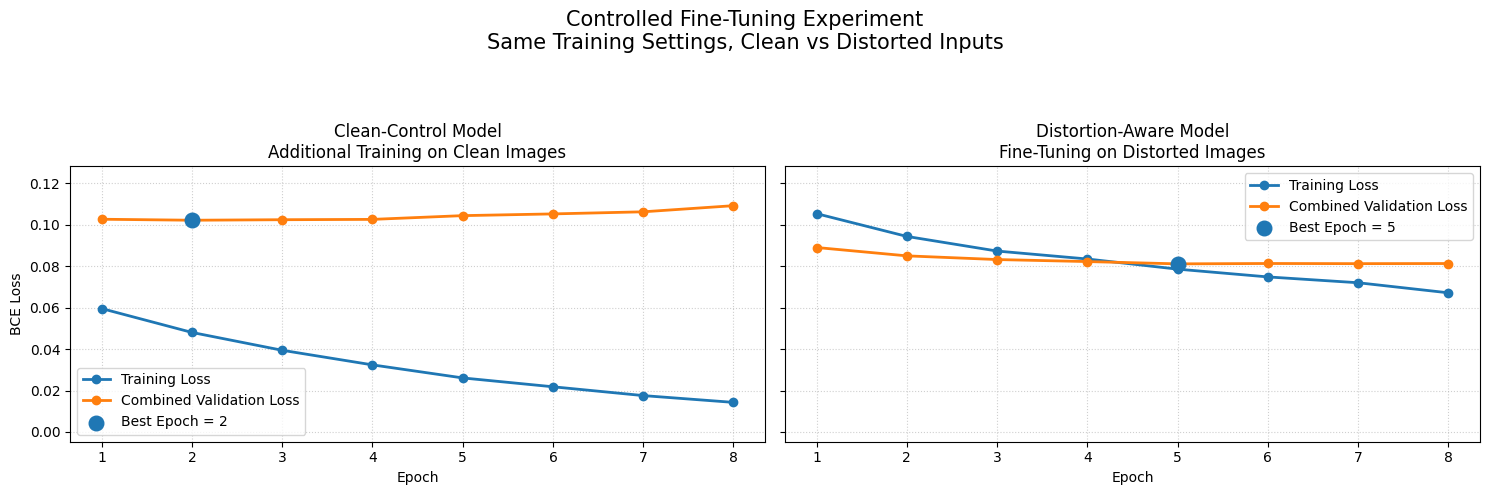


Saved controlled loss curves to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_finetuning_loss_curves.png

Cell 5.5 completed successfully.


In [ ]:
# Cell 5.5: Controlled Fine-Tuning Loss Curves
#
# Compare the training process of:
# 1. Clean-Control Model
# 2. Distortion-Aware Model

print("Generating controlled fine-tuning loss curves...")


# ---------------------------------------------------------
# 1. Load Controlled Training History
# ---------------------------------------------------------
controlled_history_path = (
    TABLES_DIR /
    "part4_controlled_finetuning_history.csv"
)

print("Looking for controlled training history at:")
print(controlled_history_path)

print(
    "History file exists:",
    controlled_history_path.exists()
)

if not controlled_history_path.exists():
    raise FileNotFoundError(
        "Controlled fine-tuning history was not found.\n"
        "Run the new Cell 5 before running this cell."
    )


controlled_history_df = pd.read_csv(
    controlled_history_path
)


# ---------------------------------------------------------
# 2. Validate Required Columns
# ---------------------------------------------------------
required_columns = {
    "model",
    "epoch",
    "train_loss",
    "clean_val_loss",
    "distorted_val_loss",
    "combined_val_loss"
}

missing_columns = required_columns.difference(
    controlled_history_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing columns in controlled history: "
        f"{sorted(missing_columns)}"
    )


print("\nControlled training history:")
display(controlled_history_df)


# ---------------------------------------------------------
# 3. Separate the Two Models
# ---------------------------------------------------------
clean_history_df = controlled_history_df[
    controlled_history_df["model"] == "clean_control"
].copy()

distorted_history_df = controlled_history_df[
    controlled_history_df["model"] == "distortion_aware"
].copy()


if clean_history_df.empty:
    raise ValueError(
        "No clean_control training history was found."
    )

if distorted_history_df.empty:
    raise ValueError(
        "No distortion_aware training history was found."
    )


# ---------------------------------------------------------
# 4. Find Best Epoch for Each Model
# ---------------------------------------------------------
clean_best_index = clean_history_df[
    "combined_val_loss"
].idxmin()

clean_best_row = controlled_history_df.loc[
    clean_best_index
]

clean_best_epoch = int(
    clean_best_row["epoch"]
)

clean_best_loss = float(
    clean_best_row["combined_val_loss"]
)


distorted_best_index = distorted_history_df[
    "combined_val_loss"
].idxmin()

distorted_best_row = controlled_history_df.loc[
    distorted_best_index
]

distorted_best_epoch = int(
    distorted_best_row["epoch"]
)

distorted_best_loss = float(
    distorted_best_row["combined_val_loss"]
)


print(
    "\nClean-control best epoch:",
    clean_best_epoch
)

print(
    "Clean-control best combined validation loss:",
    f"{clean_best_loss:.4f}"
)

print(
    "\nDistortion-aware best epoch:",
    distorted_best_epoch
)

print(
    "Distortion-aware best combined validation loss:",
    f"{distorted_best_loss:.4f}"
)


# ---------------------------------------------------------
# 5. Plot Both Training Processes
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True
)


# =========================================================
# Graph 1: Clean-Control Model
# =========================================================
axes[0].plot(
    clean_history_df["epoch"],
    clean_history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

axes[0].plot(
    clean_history_df["epoch"],
    clean_history_df["combined_val_loss"],
    marker="o",
    linewidth=2,
    label="Combined Validation Loss"
)

axes[0].scatter(
    clean_best_epoch,
    clean_best_loss,
    s=110,
    zorder=5,
    label=f"Best Epoch = {clean_best_epoch}"
)

axes[0].set_title(
    "Clean-Control Model\n"
    "Additional Training on Clean Images"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")

axes[0].set_xticks(
    clean_history_df["epoch"].astype(int)
)

axes[0].grid(
    True,
    linestyle=":",
    alpha=0.6
)

axes[0].legend()


# =========================================================
# Graph 2: Distortion-Aware Model
# =========================================================
axes[1].plot(
    distorted_history_df["epoch"],
    distorted_history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

axes[1].plot(
    distorted_history_df["epoch"],
    distorted_history_df["combined_val_loss"],
    marker="o",
    linewidth=2,
    label="Combined Validation Loss"
)

axes[1].scatter(
    distorted_best_epoch,
    distorted_best_loss,
    s=110,
    zorder=5,
    label=f"Best Epoch = {distorted_best_epoch}"
)

axes[1].set_title(
    "Distortion-Aware Model\n"
    "Fine-Tuning on Distorted Images"
)

axes[1].set_xlabel("Epoch")

axes[1].set_xticks(
    distorted_history_df["epoch"].astype(int)
)

axes[1].grid(
    True,
    linestyle=":",
    alpha=0.6
)

axes[1].legend()


# ---------------------------------------------------------
# 6. Shared Y-Axis Range
# ---------------------------------------------------------
all_loss_values = pd.concat([
    clean_history_df[
        ["train_loss", "combined_val_loss"]
    ].stack(),

    distorted_history_df[
        ["train_loss", "combined_val_loss"]
    ].stack()
])

y_min = float(
    all_loss_values.min()
)

y_max = float(
    all_loss_values.max()
)

padding = max(
    (y_max - y_min) * 0.20,
    0.003
)

axes[0].set_ylim(
    y_min - padding,
    y_max + padding
)


# ---------------------------------------------------------
# 7. Main Figure Title
# ---------------------------------------------------------
fig.suptitle(
    "Controlled Fine-Tuning Experiment\n"
    "Same Training Settings, Clean vs Distorted Inputs",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)


# ---------------------------------------------------------
# 8. Save Graph
# ---------------------------------------------------------
controlled_loss_graph_path = (
    FIGURES_DIR /
    "part4_controlled_finetuning_loss_curves.png"
)

plt.savefig(
    controlled_loss_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print("\nSaved controlled loss curves to:")
print(controlled_loss_graph_path)

print("\nCell 5.5 completed successfully.")

In [ ]:
# Load the Controlled Fine-Tuning Models
#
# 1. Clean-Control Model:
#    Additional training on clean images.
#
# 2. Distortion-Aware Model:
#    Fine-tuning on distorted images.

# ---------------------------------------------------------
# 1. Model Paths
# ---------------------------------------------------------
clean_control_model_path = (
    MODELS_DIR /
    "resnet50_multilabel_clean_control.pth"
)

distortion_aware_model_path = (
    MODELS_DIR /
    "resnet50_multilabel_distortion_aware.pth"
)


# ---------------------------------------------------------
# 2. Verify Saved Models
# ---------------------------------------------------------
print("Looking for clean-control model at:")
print(clean_control_model_path)

print(
    "Clean-control model exists:",
    clean_control_model_path.exists()
)

print("\nLooking for distortion-aware model at:")
print(distortion_aware_model_path)

print(
    "Distortion-aware model exists:",
    distortion_aware_model_path.exists()
)


if not clean_control_model_path.exists():
    raise FileNotFoundError(
        "Clean-control model was not found.\n"
        "Run Cell 5 before continuing."
    )

if not distortion_aware_model_path.exists():
    raise FileNotFoundError(
        "Distortion-aware model was not found.\n"
        "Run Cell 5 before continuing."
    )


# ---------------------------------------------------------
# 3. Load Clean-Control Model
# ---------------------------------------------------------
clean_control_model = build_resnet50_multilabel()

clean_control_model.load_state_dict(
    torch.load(
        clean_control_model_path,
        map_location=device
    )
)

clean_control_model = clean_control_model.to(device)
clean_control_model.eval()

for parameter in clean_control_model.parameters():
    parameter.requires_grad = False

print(
    "\nClean-control model loaded successfully."
)


# ---------------------------------------------------------
# 4. Load Distortion-Aware Model
# ---------------------------------------------------------
distortion_aware_model = build_resnet50_multilabel()

distortion_aware_model.load_state_dict(
    torch.load(
        distortion_aware_model_path,
        map_location=device
    )
)

distortion_aware_model = distortion_aware_model.to(device)
distortion_aware_model.eval()

for parameter in distortion_aware_model.parameters():
    parameter.requires_grad = False

print(
    "Distortion-aware model loaded successfully."
)


# ---------------------------------------------------------
# 5. Compatibility Name
#
# Some later visualization cells still use ft_model.
# ---------------------------------------------------------
ft_model = distortion_aware_model


# ---------------------------------------------------------
# 6. Final Verification
# ---------------------------------------------------------
print("\nModels ready for comparison:")
print("- clean_control_model")
print("- distortion_aware_model")

print(
    "\nControlled model loading completed successfully."
)

Looking for clean-control model at:
/content/drive/MyDrive/Digital_image_processing_project/models/resnet50_multilabel_clean_control.pth
Clean-control model exists: True

Looking for distortion-aware model at:
/content/drive/MyDrive/Digital_image_processing_project/models/resnet50_multilabel_distortion_aware.pth
Distortion-aware model exists: True

Clean-control model loaded successfully.
Distortion-aware model loaded successfully.

Models ready for comparison:
- clean_control_model
- distortion_aware_model

Controlled model loading completed successfully.


In [ ]:
# Cell 6: Controlled Comparison on Clean and Distorted Images
#
# Compare:
# 1. Clean-Control Model
#    Additional fine-tuning on clean images.
#
# 2. Distortion-Aware Model
#    Additional fine-tuning on distorted images.
#
# Both models were trained with identical settings.
# They are evaluated on the same images and conditions.

# ---------------------------------------------------------
# 1. Evaluation Parameters
# ---------------------------------------------------------
THRESHOLD = 0.3
EVAL_MAX_SAMPLES = 400

print("Starting controlled model evaluation...")
print("Threshold:", THRESHOLD)
print("Evaluation samples per condition:", EVAL_MAX_SAMPLES)
print("Number of conditions:", len(DISTORTION_CONFIGS))


# ---------------------------------------------------------
# 2. Evaluation Function
# ---------------------------------------------------------
def evaluate_model_on_loader(
    model,
    data_loader,
    threshold=0.3
):
    """
    Evaluate a multi-label classification model.

    Metrics:
    - Sample-averaged F1
    - Micro F1
    - Macro F1
    - Exact match accuracy
    - Mean SNR
    """
    model.eval()

    all_true = []
    all_pred = []
    all_snr = []

    with torch.no_grad():

        for images, labels, snr_values in data_loader:

            images = images.to(
                device,
                non_blocking=(
                    device.type == "cuda"
                )
            )

            logits = model(images)

            probabilities = torch.sigmoid(
                logits
            ).cpu().numpy()

            predictions = (
                probabilities >= threshold
            ).astype(np.float32)

            all_true.append(
                labels.numpy()
            )

            all_pred.append(
                predictions
            )

            all_snr.extend(
                snr_values.numpy().tolist()
            )


    y_true = np.vstack(
        all_true
    )

    y_pred = np.vstack(
        all_pred
    )


    # -----------------------------------------------------
    # Sample-averaged F1
    # Average F1 across individual images.
    # -----------------------------------------------------
    f1_samples = f1_score(
        y_true,
        y_pred,
        average="samples",
        zero_division=0
    )


    # -----------------------------------------------------
    # Micro F1
    # -----------------------------------------------------
    f1_micro = f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )


    # -----------------------------------------------------
    # Macro F1
    # -----------------------------------------------------
    f1_macro = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    # -----------------------------------------------------
    # Exact Match Accuracy
    # Correct only when all labels match.
    # -----------------------------------------------------
    exact_match = np.mean(
        np.all(
            y_true == y_pred,
            axis=1
        )
    )


    # -----------------------------------------------------
    # Mean finite SNR
    # Clean images have infinite SNR.
    # -----------------------------------------------------
    finite_snr_values = [
        value
        for value in all_snr
        if np.isfinite(value)
    ]

    if finite_snr_values:
        mean_snr = float(
            np.mean(
                finite_snr_values
            )
        )
    else:
        mean_snr = np.inf


    return {
        "mean_snr": mean_snr,
        "f1_samples": f1_samples,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
        "exact_match": exact_match
    }


# ---------------------------------------------------------
# 3. Evaluate Both Models on Every Condition
# ---------------------------------------------------------
results = []

for condition_index, config in enumerate(
    DISTORTION_CONFIGS,
    start=1
):

    print(
        f"\nCondition "
        f"{condition_index}/"
        f"{len(DISTORTION_CONFIGS)}:"
    )

    print(
        config["name"],
        "| params:",
        config["params"]
    )


    # -----------------------------------------------------
    # Same evaluation images and same distortion are used
    # for both models.
    # -----------------------------------------------------
    eval_dataset = (
        VOCDistortedClassificationDataset(
            voc_dataset=voc_val,
            mode="fixed",
            condition_config=config,
            max_samples=EVAL_MAX_SAMPLES,
            seed=SEED + 200
        )
    )

    eval_loader = DataLoader(
        eval_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            device.type == "cuda"
        )
    )


    # =====================================================
    # Clean-Control Model
    # =====================================================
    clean_control_metrics = (
        evaluate_model_on_loader(
            clean_control_model,
            eval_loader,
            threshold=THRESHOLD
        )
    )

    results.append({
        "model": "clean_control_resnet50",
        "condition": config["name"],
        "distortion_type": config["type"],
        "severity_level": config["severity_level"],
        "severity_label": config["severity_label"],
        "params": str(config["params"]),
        **clean_control_metrics
    })


    # =====================================================
    # Distortion-Aware Model
    # =====================================================
    distortion_aware_metrics = (
        evaluate_model_on_loader(
            distortion_aware_model,
            eval_loader,
            threshold=THRESHOLD
        )
    )

    results.append({
        "model": "distortion_aware_resnet50",
        "condition": config["name"],
        "distortion_type": config["type"],
        "severity_level": config["severity_level"],
        "severity_label": config["severity_label"],
        "params": str(config["params"]),
        **distortion_aware_metrics
    })


    # -----------------------------------------------------
    # Display condition result
    # -----------------------------------------------------
    improvement = (
        distortion_aware_metrics["f1_samples"] -
        clean_control_metrics["f1_samples"]
    )

    print(
        "Clean-control F1:",
        f"{clean_control_metrics['f1_samples']:.4f}"
    )

    print(
        "Distortion-aware F1:",
        f"{distortion_aware_metrics['f1_samples']:.4f}"
    )

    print(
        "Improvement from distorted fine-tuning:",
        f"{improvement:+.4f}"
    )


# ---------------------------------------------------------
# 4. Full Results Table
# ---------------------------------------------------------
part4_results_df = pd.DataFrame(
    results
)

part4_results_df = (
    part4_results_df
    .sort_values(
        [
            "distortion_type",
            "severity_level",
            "model"
        ],
        na_position="first"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 5. Save Full Metrics
# ---------------------------------------------------------
results_path = (
    TABLES_DIR /
    "part4_controlled_model_metrics.csv"
)

part4_results_df.to_csv(
    results_path,
    index=False
)


# ---------------------------------------------------------
# 6. Create Direct Comparison Table
# ---------------------------------------------------------
comparison_df = part4_results_df.pivot(
    index=[
        "condition",
        "distortion_type",
        "severity_level",
        "severity_label",
        "params",
        "mean_snr"
    ],
    columns="model",
    values="f1_samples"
).reset_index()

comparison_df.columns.name = None


comparison_df[
    "distortion_finetuning_improvement"
] = (
    comparison_df[
        "distortion_aware_resnet50"
    ]
    -
    comparison_df[
        "clean_control_resnet50"
    ]
)


comparison_df = (
    comparison_df
    .sort_values(
        [
            "distortion_type",
            "severity_level"
        ],
        na_position="first"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 7. Save Comparison Table
# ---------------------------------------------------------
comparison_path = (
    TABLES_DIR /
    "part4_controlled_finetuning_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


# ---------------------------------------------------------
# 8. Summary on Distorted Conditions Only
# ---------------------------------------------------------
distorted_comparison_df = comparison_df[
    comparison_df["distortion_type"] != "clean"
].copy()


clean_control_mean_f1 = (
    distorted_comparison_df[
        "clean_control_resnet50"
    ].mean()
)

distortion_aware_mean_f1 = (
    distorted_comparison_df[
        "distortion_aware_resnet50"
    ].mean()
)

mean_improvement = (
    distortion_aware_mean_f1 -
    clean_control_mean_f1
)


summary_df = pd.DataFrame([
    {
        "model": "clean_control_resnet50",
        "mean_f1_on_distorted_images": (
            clean_control_mean_f1
        )
    },
    {
        "model": "distortion_aware_resnet50",
        "mean_f1_on_distorted_images": (
            distortion_aware_mean_f1
        )
    }
])


summary_path = (
    TABLES_DIR /
    "part4_controlled_finetuning_summary_metrics.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


# ---------------------------------------------------------
# 9. Display Results
# ---------------------------------------------------------
print("\nEvaluation completed successfully.")

print("\nSaved full metrics to:")
print(results_path)

print("\nSaved comparison table to:")
print(comparison_path)

print("\nSaved summary metrics to:")
print(summary_path)


print("\nMean performance on all distorted conditions:")

print(
    "Clean-control mean F1:",
    f"{clean_control_mean_f1:.4f}"
)

print(
    "Distortion-aware mean F1:",
    f"{distortion_aware_mean_f1:.4f}"
)

print(
    "Mean improvement from distorted fine-tuning:",
    f"{mean_improvement:+.4f}"
)


print("\nFull controlled results:")
display(part4_results_df)


print("\nClean Control vs Distortion-Aware:")
display(
    comparison_df[
        [
            "condition",
            "distortion_type",
            "severity_level",
            "mean_snr",
            "clean_control_resnet50",
            "distortion_aware_resnet50",
            "distortion_finetuning_improvement"
        ]
    ]
)

print("\nSummary:")
display(summary_df)

print("\nCell 6 completed successfully.")

Starting controlled model evaluation...
Threshold: 0.3
Evaluation samples per condition: 400
Number of conditions: 19

Condition 1/19:
clean | params: {}
Clean-control F1: 0.8511
Distortion-aware F1: 0.8565
Improvement from distorted fine-tuning: +0.0054

Condition 2/19:
salt_pepper_L1 | params: {'amount': 0.005}
Clean-control F1: 0.8299
Distortion-aware F1: 0.8379
Improvement from distorted fine-tuning: +0.0080

Condition 3/19:
salt_pepper_L2 | params: {'amount': 0.01}
Clean-control F1: 0.8129
Distortion-aware F1: 0.8214
Improvement from distorted fine-tuning: +0.0085

Condition 4/19:
salt_pepper_L3 | params: {'amount': 0.03}
Clean-control F1: 0.7865
Distortion-aware F1: 0.8164
Improvement from distorted fine-tuning: +0.0299

Condition 5/19:
salt_pepper_L4 | params: {'amount': 0.07}
Clean-control F1: 0.7201
Distortion-aware F1: 0.8098
Improvement from distorted fine-tuning: +0.0897

Condition 6/19:
salt_pepper_L5 | params: {'amount': 0.15}
Clean-control F1: 0.6305
Distortion-aware F1:

,model,condition,distortion_type,severity_level,severity_label,params,mean_snr,f1_samples,f1_micro,f1_macro,exact_match
0,clean_control_resnet50,clean,clean,0,Clean,{},inf,0.851077,0.834437,0.829914,0.6325
1,distortion_aware_resnet50,clean,clean,0,Clean,{},inf,0.856524,0.841413,0.840822,0.6350
2,clean_control_resnet50,motion_blur_L1,motion_blur,1,L1,{'kernel_size': 3},24.021604,0.837065,0.821429,0.818939,0.5975
3,distortion_aware_resnet50,motion_blur_L1,motion_blur,1,L1,{'kernel_size': 3},24.021604,0.854137,0.838235,0.834793,0.6275
4,clean_control_resnet50,motion_blur_L2,motion_blur,2,L2,{'kernel_size': 7},19.591692,0.813012,0.798361,0.788013,0.5650
5,distortion_aware_resnet50,motion_blur_L2,motion_blur,2,L2,{'kernel_size': 7},19.591692,0.834625,0.821895,0.814536,0.5825
6,clean_control_resnet50,motion_blur_L3,motion_blur,3,L3,{'kernel_size': 11},18.020308,0.757190,0.758679,0.731540,0.5050
7,distortion_aware_resnet50,motion_blur_L3,motion_blur,3,L3,{'kernel_size': 11},18.020308,0.831821,0.812955,0.800503,0.5750
8,clean_control_resnet50,motion_blur_L4,motion_blur,4,L4,{'kernel_size': 15},17.030957,0.701202,0.721137,0.667112,0.4625
9,distortion_aware_resnet50,motion_blur_L4,motion_blur,4,L4,{'kernel_size': 15},17.030957,0.819490,0.797448,0.788598,0.5625



Clean Control vs Distortion-Aware:


,condition,distortion_type,severity_level,mean_snr,clean_control_resnet50,distortion_aware_resnet50,distortion_finetuning_improvement
0,clean,clean,0,inf,0.851077,0.856524,0.005446
1,motion_blur_L1,motion_blur,1,24.021604,0.837065,0.854137,0.017071
2,motion_blur_L2,motion_blur,2,19.591692,0.813012,0.834625,0.021613
3,motion_blur_L3,motion_blur,3,18.020308,0.757190,0.831821,0.074631
4,motion_blur_L4,motion_blur,4,17.030957,0.701202,0.819490,0.118288
5,motion_blur_L5,motion_blur,5,15.498189,0.552625,0.739560,0.186935
6,motion_blur_L6,motion_blur,6,14.129062,0.344167,0.644054,0.299887
7,overexposure_L1,overexposure,1,15.906503,0.848125,0.847940,-0.000185
8,overexposure_L2,overexposure,2,8.520158,0.838411,0.848405,0.009994
9,overexposure_L3,overexposure,3,4.196927,0.843107,0.848435,0.005327



Summary:


,model,mean_f1_on_distorted_images
0,clean_control_resnet50,0.719452
1,distortion_aware_resnet50,0.803127



Cell 6 completed successfully.


In [ ]:
# Cell 6.5: Controlled Per-Class and Per-SNR Evaluation
#
# Compare:
# 1. Clean-Control Model
# 2. Distortion-Aware Model
#
# The same images, distortion conditions, threshold,
# and class labels are used for both models.

print(
    "Computing controlled per-class and per-SNR metrics..."
)


# ---------------------------------------------------------
# 1. Storage
# ---------------------------------------------------------
per_class_records = []


# ---------------------------------------------------------
# 2. Evaluate Every Condition
# ---------------------------------------------------------
for condition_index, config in enumerate(
    DISTORTION_CONFIGS,
    start=1
):

    print(
        f"\nCondition "
        f"{condition_index}/"
        f"{len(DISTORTION_CONFIGS)}:"
    )

    print(
        config["name"],
        "| params:",
        config["params"]
    )


    # -----------------------------------------------------
    # Use the same evaluation images as Cell 6
    # -----------------------------------------------------
    eval_dataset = (
        VOCDistortedClassificationDataset(
            voc_dataset=voc_val,
            mode="fixed",
            condition_config=config,
            max_samples=EVAL_MAX_SAMPLES,
            seed=SEED + 200
        )
    )

    eval_loader = DataLoader(
        eval_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            device.type == "cuda"
        )
    )


    # -----------------------------------------------------
    # Collect ground truth and predictions
    # -----------------------------------------------------
    all_true = []

    all_predictions = {
        "clean_control_resnet50": [],
        "distortion_aware_resnet50": []
    }

    all_snr = []


    clean_control_model.eval()
    distortion_aware_model.eval()


    with torch.no_grad():

        for images, labels, snr_values in eval_loader:

            images = images.to(
                device,
                non_blocking=(
                    device.type == "cuda"
                )
            )


            # =============================================
            # Clean-Control Predictions
            # =============================================
            clean_logits = clean_control_model(
                images
            )

            clean_probabilities = torch.sigmoid(
                clean_logits
            ).cpu().numpy()

            clean_predictions = (
                clean_probabilities >= THRESHOLD
            ).astype(
                np.float32
            )


            # =============================================
            # Distortion-Aware Predictions
            # =============================================
            distortion_logits = (
                distortion_aware_model(
                    images
                )
            )

            distortion_probabilities = torch.sigmoid(
                distortion_logits
            ).cpu().numpy()

            distortion_predictions = (
                distortion_probabilities >= THRESHOLD
            ).astype(
                np.float32
            )


            # =============================================
            # Store Results
            # =============================================
            all_true.append(
                labels.numpy()
            )

            all_predictions[
                "clean_control_resnet50"
            ].append(
                clean_predictions
            )

            all_predictions[
                "distortion_aware_resnet50"
            ].append(
                distortion_predictions
            )

            all_snr.extend(
                snr_values.numpy().tolist()
            )


    # -----------------------------------------------------
    # Combine All Batches
    # -----------------------------------------------------
    y_true = np.vstack(
        all_true
    )

    model_prediction_arrays = {
        model_name: np.vstack(
            prediction_batches
        )
        for (
            model_name,
            prediction_batches
        ) in all_predictions.items()
    }


    # -----------------------------------------------------
    # Mean SNR for this condition
    # -----------------------------------------------------
    finite_snr_values = [
        value
        for value in all_snr
        if np.isfinite(value)
    ]

    if finite_snr_values:

        mean_snr = float(
            np.mean(
                finite_snr_values
            )
        )

    else:

        mean_snr = np.inf


    # -----------------------------------------------------
    # Per-Class Metrics for Both Models
    # -----------------------------------------------------
    for (
        model_name,
        y_pred
    ) in model_prediction_arrays.items():

        for (
            class_index,
            class_name
        ) in enumerate(
            VOC_CLASSES
        ):

            class_true = y_true[
                :,
                class_index
            ]

            class_prediction = y_pred[
                :,
                class_index
            ]


            class_f1 = f1_score(
                class_true,
                class_prediction,
                zero_division=0
            )

            support = int(
                class_true.sum()
            )

            predicted_positive = int(
                class_prediction.sum()
            )


            per_class_records.append({
                "model": model_name,
                "condition": config["name"],
                "distortion_type": config["type"],
                "severity_level": (
                    config["severity_level"]
                ),
                "severity_label": (
                    config["severity_label"]
                ),
                "params": str(
                    config["params"]
                ),
                "class": class_name,
                "mean_snr": mean_snr,
                "class_f1_score": class_f1,
                "support": support,
                "predicted_positive": (
                    predicted_positive
                )
            })


# ---------------------------------------------------------
# 3. Create Full Per-Class Table
# ---------------------------------------------------------
part4_per_class_df = pd.DataFrame(
    per_class_records
)

part4_per_class_df = (
    part4_per_class_df
    .sort_values(
        [
            "distortion_type",
            "severity_level",
            "model",
            "class"
        ],
        na_position="first"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 4. Save Full Per-Class and Per-SNR Results
# ---------------------------------------------------------
per_class_path = (
    TABLES_DIR /
    "part4_controlled_per_class_per_snr_metrics.csv"
)

part4_per_class_df.to_csv(
    per_class_path,
    index=False
)


# ---------------------------------------------------------
# 5. Summary by Model and Distortion Type
# ---------------------------------------------------------
per_class_summary_df = (
    part4_per_class_df[
        part4_per_class_df[
            "distortion_type"
        ] != "clean"
    ]
    .groupby(
        [
            "model",
            "distortion_type"
        ],
        as_index=False
    )
    .agg(
        mean_class_f1=(
            "class_f1_score",
            "mean"
        ),
        mean_snr=(
            "mean_snr",
            "mean"
        )
    )
)


# ---------------------------------------------------------
# 6. Direct Per-Class Improvement Table
# ---------------------------------------------------------
distorted_per_class_df = (
    part4_per_class_df[
        part4_per_class_df[
            "distortion_type"
        ] != "clean"
    ]
    .copy()
)

class_comparison_df = (
    distorted_per_class_df
    .groupby(
        [
            "model",
            "class"
        ],
        as_index=False
    )[
        "class_f1_score"
    ]
    .mean()
    .pivot(
        index="class",
        columns="model",
        values="class_f1_score"
    )
    .reset_index()
)

class_comparison_df.columns.name = None

class_comparison_df[
    "class_f1_improvement"
] = (
    class_comparison_df[
        "distortion_aware_resnet50"
    ]
    -
    class_comparison_df[
        "clean_control_resnet50"
    ]
)

class_comparison_df = (
    class_comparison_df
    .sort_values(
        "class_f1_improvement",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


class_comparison_path = (
    TABLES_DIR /
    "part4_controlled_per_class_comparison.csv"
)

class_comparison_df.to_csv(
    class_comparison_path,
    index=False
)


# ---------------------------------------------------------
# 7. Display Results
# ---------------------------------------------------------
print(
    "\nPer-class and per-SNR evaluation "
    "completed successfully."
)

print("\nSaved full per-class metrics to:")
print(per_class_path)

print("\nSaved per-class comparison to:")
print(class_comparison_path)


print("\nSummary by model and distortion type:")
display(
    per_class_summary_df
)


print("\nAverage performance per class:")
display(
    class_comparison_df
)


print("\nFirst rows of the full results:")
display(
    part4_per_class_df.head(40)
)

print("\nCell 6.5 completed successfully.")

Computing controlled per-class and per-SNR metrics...

Condition 1/19:
clean | params: {}

Condition 2/19:
salt_pepper_L1 | params: {'amount': 0.005}

Condition 3/19:
salt_pepper_L2 | params: {'amount': 0.01}

Condition 4/19:
salt_pepper_L3 | params: {'amount': 0.03}

Condition 5/19:
salt_pepper_L4 | params: {'amount': 0.07}

Condition 6/19:
salt_pepper_L5 | params: {'amount': 0.15}

Condition 7/19:
salt_pepper_L6 | params: {'amount': 0.3}

Condition 8/19:
overexposure_L1 | params: {'factor': 1.1, 'bias': 10}

Condition 9/19:
overexposure_L2 | params: {'factor': 1.3, 'bias': 20}

Condition 10/19:
overexposure_L3 | params: {'factor': 1.6, 'bias': 35}

Condition 11/19:
overexposure_L4 | params: {'factor': 2.0, 'bias': 50}

Condition 12/19:
overexposure_L5 | params: {'factor': 2.5, 'bias': 75}

Condition 13/19:
overexposure_L6 | params: {'factor': 3.2, 'bias': 100}

Condition 14/19:
motion_blur_L1 | params: {'kernel_size': 3}

Condition 15/19:
motion_blur_L2 | params: {'kernel_size': 7}



,model,distortion_type,mean_class_f1,mean_snr
0,clean_control_resnet50,motion_blur,0.634415,18.048635
1,clean_control_resnet50,overexposure,0.771757,4.943244
2,clean_control_resnet50,salt_pepper,0.679457,12.479828
3,distortion_aware_resnet50,motion_blur,0.766530,18.048635
4,distortion_aware_resnet50,overexposure,0.807006,4.943244
5,distortion_aware_resnet50,salt_pepper,0.784087,12.479828



Average performance per class:


,class,clean_control_resnet50,distortion_aware_resnet50,class_f1_improvement
0,sofa,0.497831,0.730440,0.232609
1,diningtable,0.466730,0.655090,0.188360
2,bicycle,0.665456,0.794698,0.129242
3,chair,0.515864,0.644026,0.128162
4,sheep,0.589342,0.709781,0.120439
5,bottle,0.466028,0.580219,0.114191
6,pottedplant,0.532089,0.640656,0.108567
7,aeroplane,0.834896,0.935893,0.100998
8,cow,0.600727,0.698354,0.097627
9,dog,0.786017,0.864652,0.078635



First rows of the full results:


,model,condition,distortion_type,severity_level,severity_label,params,class,mean_snr,class_f1_score,support,predicted_positive
0,clean_control_resnet50,clean,clean,0,Clean,{},aeroplane,inf,0.981818,27,28
1,clean_control_resnet50,clean,clean,0,Clean,{},bicycle,inf,0.857143,20,15
2,clean_control_resnet50,clean,clean,0,Clean,{},bird,inf,0.926829,21,20
3,clean_control_resnet50,clean,clean,0,Clean,{},boat,inf,0.903226,15,16
4,clean_control_resnet50,clean,clean,0,Clean,{},bottle,inf,0.652174,24,22
5,clean_control_resnet50,clean,clean,0,Clean,{},bus,inf,0.972973,18,19
6,clean_control_resnet50,clean,clean,0,Clean,{},car,inf,0.701299,42,35
7,clean_control_resnet50,clean,clean,0,Clean,{},cat,inf,0.947368,28,29
8,clean_control_resnet50,clean,clean,0,Clean,{},chair,inf,0.675000,37,43
9,clean_control_resnet50,clean,clean,0,Clean,{},cow,inf,0.750000,16,16



Cell 6.5 completed successfully.


Generating controlled per-class comparison graphs...


,class,clean_control_resnet50,distortion_aware_resnet50,class_f1_improvement
0,sofa,0.497831,0.730440,0.232609
1,diningtable,0.466730,0.655090,0.188360
2,bicycle,0.665456,0.794698,0.129242
3,chair,0.515864,0.644026,0.128162
4,sheep,0.589342,0.709781,0.120439
5,bottle,0.466028,0.580219,0.114191
6,pottedplant,0.532089,0.640656,0.108567
7,aeroplane,0.834896,0.935893,0.100998
8,cow,0.600727,0.698354,0.097627
9,dog,0.786017,0.864652,0.078635


Clean-control mean class F1: 0.6952
Distortion-aware mean class F1: 0.7859
Mean class improvement: +0.0907


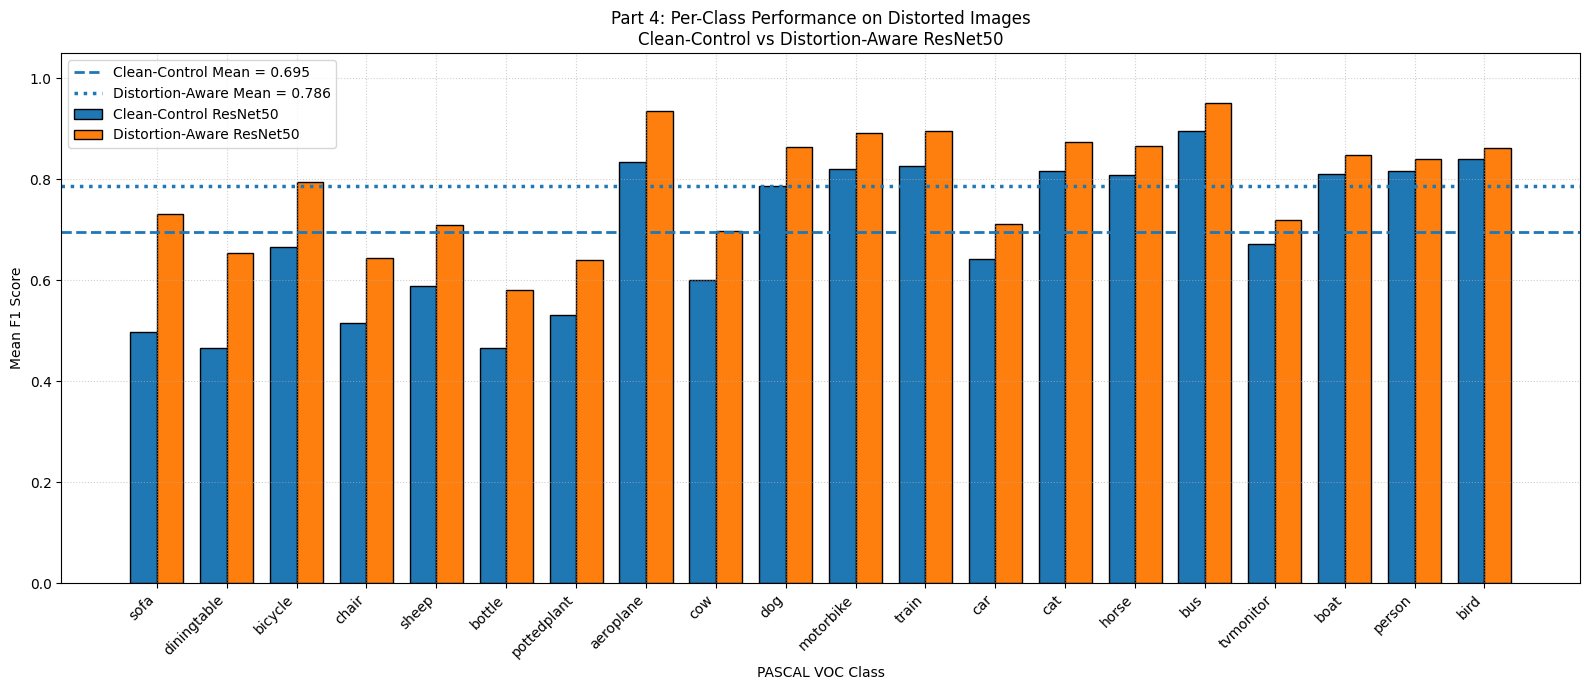


Saved per-class comparison graph to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_per_class_comparison.png


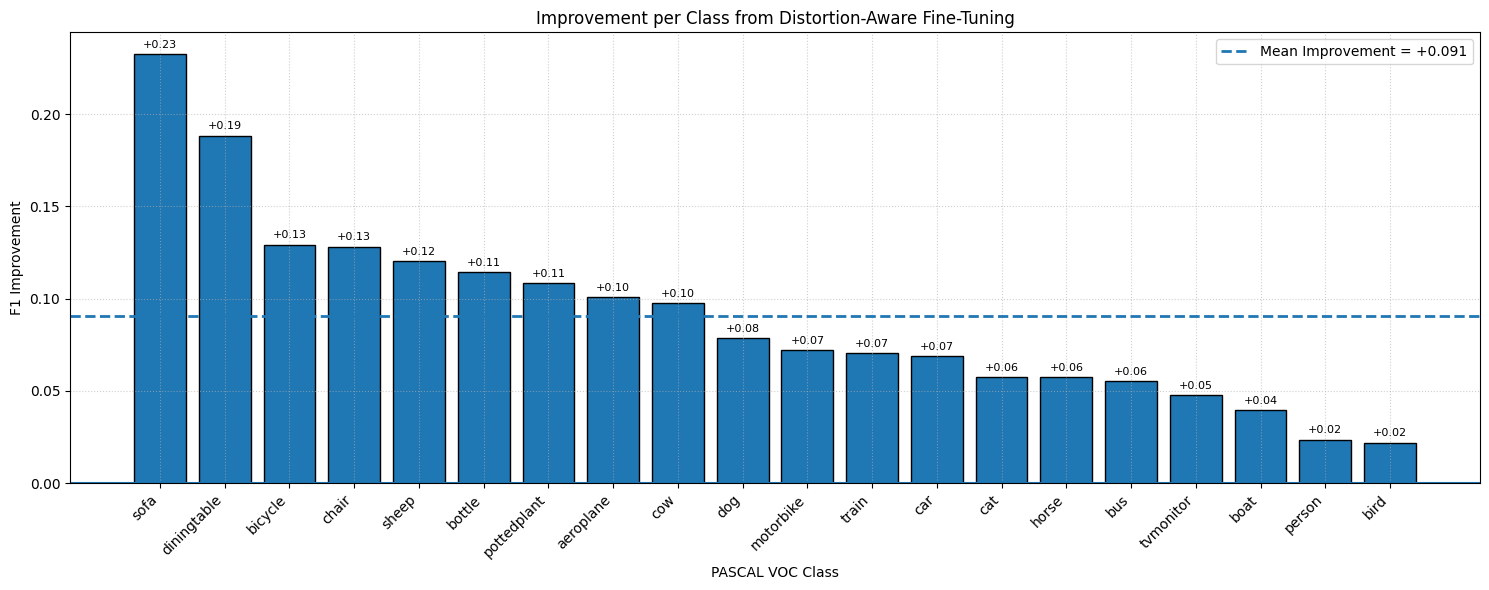


Saved per-class improvement graph to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_per_class_improvement.png

Cell 6.6 completed successfully.


In [ ]:
# Cell 6.6: Controlled Per-Class Performance Comparison
#
# Compare average F1 per class on all distorted conditions:
# 1. Clean-Control Model
# 2. Distortion-Aware Model

print("Generating controlled per-class comparison graphs...")


# ---------------------------------------------------------
# 1. Verify Required Data
# ---------------------------------------------------------
required_columns = {
    "class",
    "clean_control_resnet50",
    "distortion_aware_resnet50",
    "class_f1_improvement"
}

missing_columns = required_columns.difference(
    class_comparison_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing columns in class comparison table: "
        f"{sorted(missing_columns)}"
    )


# ---------------------------------------------------------
# 2. Sort Classes by Distortion-Aware Improvement
# ---------------------------------------------------------
plot_class_df = class_comparison_df.sort_values(
    "class_f1_improvement",
    ascending=False
).reset_index(drop=True)

display(plot_class_df)


# ---------------------------------------------------------
# 3. Mean F1 Values
# ---------------------------------------------------------
clean_control_class_mean = (
    plot_class_df[
        "clean_control_resnet50"
    ].mean()
)

distortion_aware_class_mean = (
    plot_class_df[
        "distortion_aware_resnet50"
    ].mean()
)

mean_class_improvement = (
    plot_class_df[
        "class_f1_improvement"
    ].mean()
)


print(
    "Clean-control mean class F1:",
    f"{clean_control_class_mean:.4f}"
)

print(
    "Distortion-aware mean class F1:",
    f"{distortion_aware_class_mean:.4f}"
)

print(
    "Mean class improvement:",
    f"{mean_class_improvement:+.4f}"
)


# =========================================================
# Graph 1: Per-Class F1 Comparison
# =========================================================
x = np.arange(
    len(plot_class_df)
)

width = 0.38

fig, ax = plt.subplots(
    figsize=(16, 7)
)


ax.bar(
    x - width / 2,
    plot_class_df[
        "clean_control_resnet50"
    ],
    width,
    label="Clean-Control ResNet50",
    edgecolor="black"
)

ax.bar(
    x + width / 2,
    plot_class_df[
        "distortion_aware_resnet50"
    ],
    width,
    label="Distortion-Aware ResNet50",
    edgecolor="black"
)


# Mean lines
ax.axhline(
    y=clean_control_class_mean,
    linestyle="--",
    linewidth=2,
    label=(
        f"Clean-Control Mean = "
        f"{clean_control_class_mean:.3f}"
    )
)

ax.axhline(
    y=distortion_aware_class_mean,
    linestyle=":",
    linewidth=2.5,
    label=(
        f"Distortion-Aware Mean = "
        f"{distortion_aware_class_mean:.3f}"
    )
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_class_df["class"],
    rotation=45,
    ha="right"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_xlabel(
    "PASCAL VOC Class"
)

ax.set_ylabel(
    "Mean F1 Score"
)

ax.set_title(
    "Part 4: Per-Class Performance on Distorted Images\n"
    "Clean-Control vs Distortion-Aware ResNet50"
)

ax.legend()

ax.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.tight_layout()


per_class_comparison_graph_path = (
    FIGURES_DIR /
    "part4_controlled_per_class_comparison.png"
)

plt.savefig(
    per_class_comparison_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved per-class comparison graph to:"
)

print(
    per_class_comparison_graph_path
)


# =========================================================
# Graph 2: Improvement per Class
# =========================================================
fig, ax = plt.subplots(
    figsize=(15, 6)
)

bars = ax.bar(
    plot_class_df["class"],
    plot_class_df[
        "class_f1_improvement"
    ],
    edgecolor="black"
)


ax.axhline(
    y=0,
    linewidth=1.5
)

ax.axhline(
    y=mean_class_improvement,
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean Improvement = "
        f"{mean_class_improvement:+.3f}"
    )
)


# Add improvement values above bars
for bar in bars:

    height = bar.get_height()

    vertical_offset = (
        3
        if height >= 0
        else -12
    )

    vertical_alignment = (
        "bottom"
        if height >= 0
        else "top"
    )

    ax.annotate(
        f"{height:+.2f}",
        xy=(
            bar.get_x() +
            bar.get_width() / 2,
            height
        ),
        xytext=(
            0,
            vertical_offset
        ),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=8
    )


ax.set_xticks(
    np.arange(
        len(plot_class_df)
    )
)

ax.set_xticklabels(
    plot_class_df["class"],
    rotation=45,
    ha="right"
)

ax.set_xlabel(
    "PASCAL VOC Class"
)

ax.set_ylabel(
    "F1 Improvement"
)

ax.set_title(
    "Improvement per Class from Distortion-Aware Fine-Tuning"
)

ax.legend()

ax.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.tight_layout()


per_class_improvement_graph_path = (
    FIGURES_DIR /
    "part4_controlled_per_class_improvement.png"
)

plt.savefig(
    per_class_improvement_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved per-class improvement graph to:"
)

print(
    per_class_improvement_graph_path
)

print(
    "\nCell 6.6 completed successfully."
)

Generating controlled fine-tuning comparison graphs...


,condition,clean_control_resnet50,distortion_aware_resnet50,improvement
0,salt_pepper_L1,0.829893,0.837893,0.008000
1,salt_pepper_L2,0.812881,0.821387,0.008506
2,salt_pepper_L3,0.786470,0.816411,0.029940
3,salt_pepper_L4,0.720131,0.809815,0.089685
4,salt_pepper_L5,0.630500,0.779679,0.149179
5,salt_pepper_L6,0.469833,0.739512,0.269679
6,overexposure_L1,0.848125,0.847940,-0.000185
7,overexposure_L2,0.838411,0.848405,0.009994
8,overexposure_L3,0.843107,0.848435,0.005327
9,overexposure_L4,0.806399,0.821095,0.014696


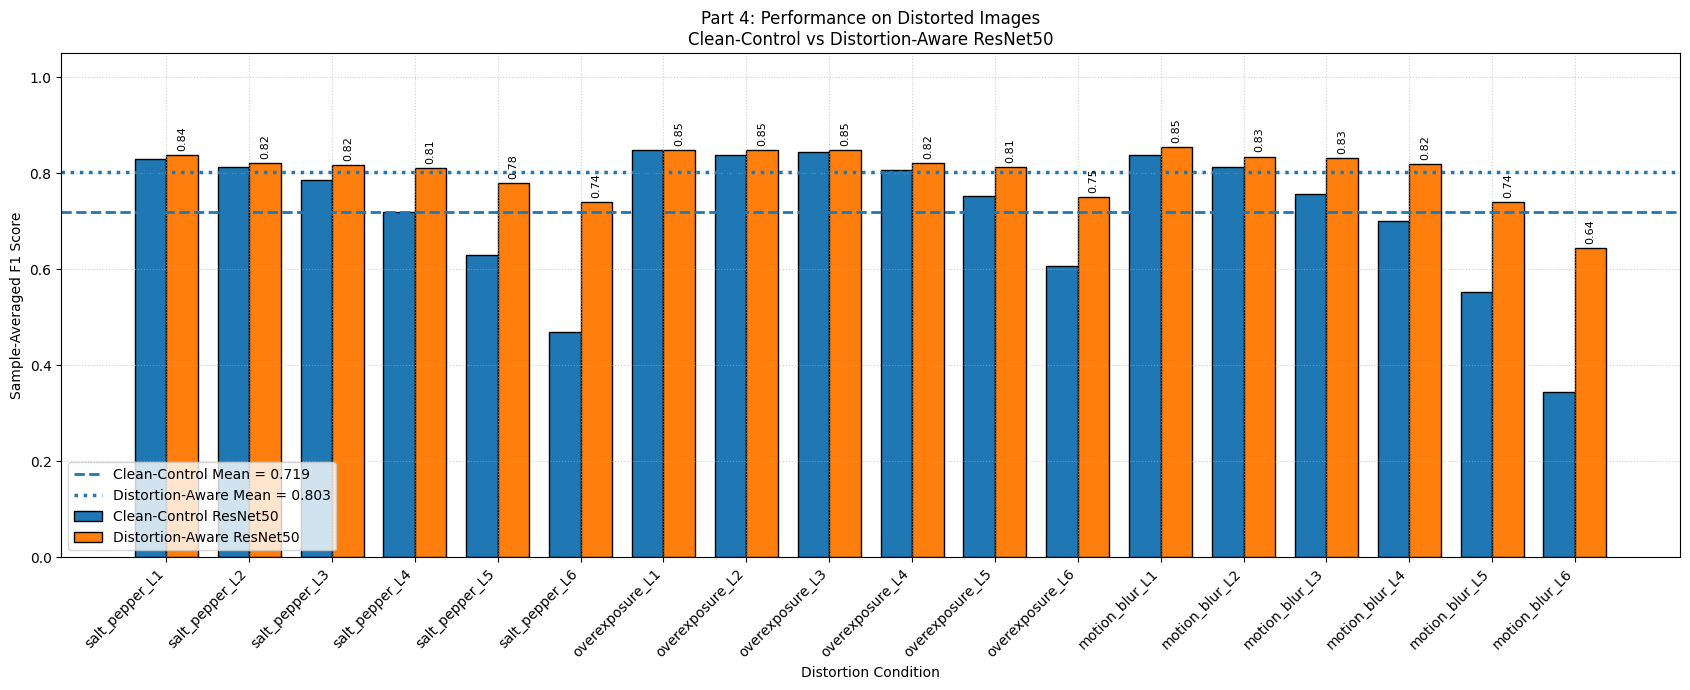


Saved all-conditions graph to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_finetuning_all_conditions.png

Mean F1 per distortion type:


,distortion_type,clean_control_resnet50,distortion_aware_resnet50,improvement
0,salt_pepper,0.708285,0.800783,0.092498
1,overexposure,0.782528,0.821316,0.038789
2,motion_blur,0.667544,0.787281,0.119737


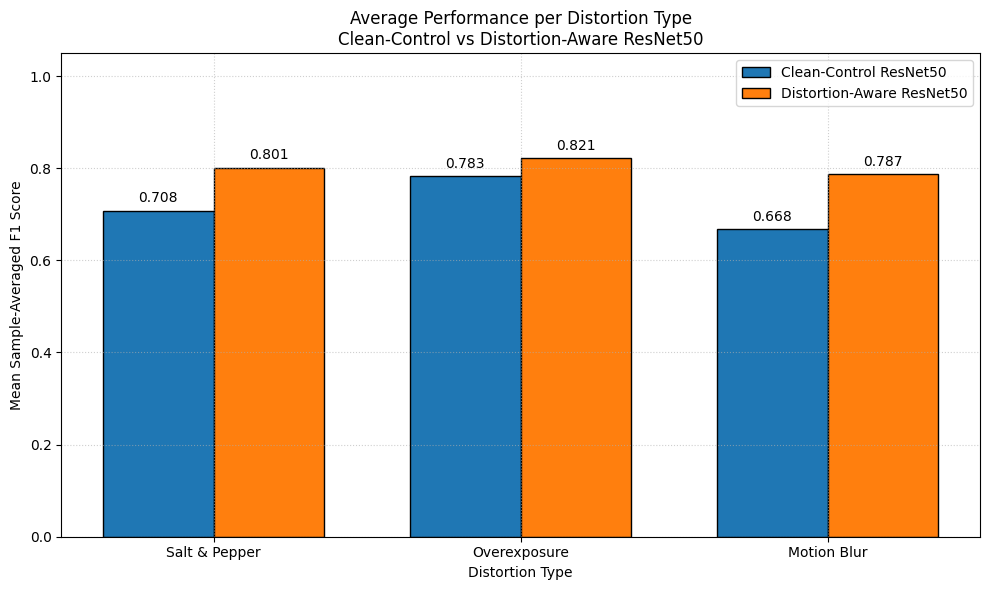


Saved distortion-type graph to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_finetuning_per_distortion_type.png

Overall distorted-image results:
Clean-control mean F1: 0.7195
Distortion-aware mean F1: 0.8031
Mean improvement: +0.0837

Cell 7 completed successfully.


In [ ]:
# Cell 7: Controlled Fine-Tuning Comparison Graphs
#
# Compare:
# 1. Clean-Control ResNet50
# 2. Distortion-Aware ResNet50
#
# Both models were trained using identical settings.
# The only difference was clean versus distorted training inputs.

print("Generating controlled fine-tuning comparison graphs...")


# ---------------------------------------------------------
# 1. Verify Results
# ---------------------------------------------------------
required_columns = {
    "model",
    "condition",
    "distortion_type",
    "severity_level",
    "f1_samples"
}

missing_columns = required_columns.difference(
    part4_results_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing columns in Part 4 results: "
        f"{sorted(missing_columns)}"
    )


# Keep distorted conditions only
distorted_plot_df = part4_results_df[
    part4_results_df["distortion_type"] != "clean"
].copy()


# ---------------------------------------------------------
# 2. Create an Ordered Condition Label
# ---------------------------------------------------------
distortion_order = {
    "salt_pepper": 0,
    "overexposure": 1,
    "motion_blur": 2
}

distorted_plot_df["distortion_order"] = (
    distorted_plot_df[
        "distortion_type"
    ].map(
        distortion_order
    )
)

distorted_plot_df = distorted_plot_df.sort_values(
    [
        "distortion_order",
        "severity_level",
        "model"
    ]
).reset_index(drop=True)


# =========================================================
# GRAPH 1:
# F1 for Every Distortion Level
# =========================================================
condition_comparison_df = distorted_plot_df.pivot(
    index=[
        "distortion_order",
        "distortion_type",
        "severity_level",
        "condition"
    ],
    columns="model",
    values="f1_samples"
).reset_index()

condition_comparison_df.columns.name = None

condition_comparison_df = (
    condition_comparison_df
    .sort_values(
        [
            "distortion_order",
            "severity_level"
        ]
    )
    .reset_index(
        drop=True
    )
)


condition_comparison_df[
    "improvement"
] = (
    condition_comparison_df[
        "distortion_aware_resnet50"
    ]
    -
    condition_comparison_df[
        "clean_control_resnet50"
    ]
)


display(
    condition_comparison_df[
        [
            "condition",
            "clean_control_resnet50",
            "distortion_aware_resnet50",
            "improvement"
        ]
    ]
)


x = np.arange(
    len(condition_comparison_df)
)

width = 0.38


clean_control_mean = (
    condition_comparison_df[
        "clean_control_resnet50"
    ].mean()
)

distortion_aware_mean = (
    condition_comparison_df[
        "distortion_aware_resnet50"
    ].mean()
)


fig, ax = plt.subplots(
    figsize=(17, 7)
)


clean_bars = ax.bar(
    x - width / 2,
    condition_comparison_df[
        "clean_control_resnet50"
    ],
    width,
    label="Clean-Control ResNet50",
    edgecolor="black"
)


distortion_bars = ax.bar(
    x + width / 2,
    condition_comparison_df[
        "distortion_aware_resnet50"
    ],
    width,
    label="Distortion-Aware ResNet50",
    edgecolor="black"
)


# Mean lines
ax.axhline(
    y=clean_control_mean,
    linestyle="--",
    linewidth=2,
    label=(
        f"Clean-Control Mean = "
        f"{clean_control_mean:.3f}"
    )
)

ax.axhline(
    y=distortion_aware_mean,
    linestyle=":",
    linewidth=2.5,
    label=(
        f"Distortion-Aware Mean = "
        f"{distortion_aware_mean:.3f}"
    )
)


# Add values above the distortion-aware bars
for bar in distortion_bars:

    height = bar.get_height()

    ax.annotate(
        f"{height:.2f}",
        xy=(
            bar.get_x() +
            bar.get_width() / 2,
            height
        ),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    condition_comparison_df[
        "condition"
    ],
    rotation=45,
    ha="right"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_xlabel(
    "Distortion Condition"
)

ax.set_ylabel(
    "Sample-Averaged F1 Score"
)

ax.set_title(
    "Part 4: Performance on Distorted Images\n"
    "Clean-Control vs Distortion-Aware ResNet50"
)

ax.legend(
    loc="lower left"
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.tight_layout()


condition_graph_path = (
    FIGURES_DIR /
    "part4_controlled_finetuning_all_conditions.png"
)

plt.savefig(
    condition_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved all-conditions graph to:"
)

print(
    condition_graph_path
)


# =========================================================
# GRAPH 2:
# Mean F1 per Distortion Type
# =========================================================
distortion_type_summary_df = (
    distorted_plot_df
    .groupby(
        [
            "model",
            "distortion_type"
        ],
        as_index=False
    )[
        "f1_samples"
    ]
    .mean()
)


distortion_type_comparison_df = (
    distortion_type_summary_df
    .pivot(
        index="distortion_type",
        columns="model",
        values="f1_samples"
    )
    .reset_index()
)

distortion_type_comparison_df.columns.name = None


distortion_type_comparison_df[
    "distortion_order"
] = (
    distortion_type_comparison_df[
        "distortion_type"
    ].map(
        distortion_order
    )
)

distortion_type_comparison_df = (
    distortion_type_comparison_df
    .sort_values(
        "distortion_order"
    )
    .reset_index(
        drop=True
    )
)


distortion_type_comparison_df[
    "improvement"
] = (
    distortion_type_comparison_df[
        "distortion_aware_resnet50"
    ]
    -
    distortion_type_comparison_df[
        "clean_control_resnet50"
    ]
)


print(
    "\nMean F1 per distortion type:"
)

display(
    distortion_type_comparison_df[
        [
            "distortion_type",
            "clean_control_resnet50",
            "distortion_aware_resnet50",
            "improvement"
        ]
    ]
)


x = np.arange(
    len(distortion_type_comparison_df)
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(10, 6)
)


clean_type_bars = ax.bar(
    x - width / 2,
    distortion_type_comparison_df[
        "clean_control_resnet50"
    ],
    width,
    label="Clean-Control ResNet50",
    edgecolor="black"
)


distortion_type_bars = ax.bar(
    x + width / 2,
    distortion_type_comparison_df[
        "distortion_aware_resnet50"
    ],
    width,
    label="Distortion-Aware ResNet50",
    edgecolor="black"
)


# Add values above all bars
for bars in [
    clean_type_bars,
    distortion_type_bars
]:

    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(
                bar.get_x() +
                bar.get_width() / 2,
                height
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10
        )


x_labels = [
    "Salt & Pepper",
    "Overexposure",
    "Motion Blur"
]


ax.set_xticks(
    x
)

ax.set_xticklabels(
    x_labels
)

ax.set_ylim(
    0,
    1.05
)

ax.set_xlabel(
    "Distortion Type"
)

ax.set_ylabel(
    "Mean Sample-Averaged F1 Score"
)

ax.set_title(
    "Average Performance per Distortion Type\n"
    "Clean-Control vs Distortion-Aware ResNet50"
)

ax.legend()

ax.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.tight_layout()


distortion_type_graph_path = (
    FIGURES_DIR /
    "part4_controlled_finetuning_per_distortion_type.png"
)

plt.savefig(
    distortion_type_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved distortion-type graph to:"
)

print(
    distortion_type_graph_path
)


# ---------------------------------------------------------
# 3. Final Numerical Summary
# ---------------------------------------------------------
overall_clean_control_mean = (
    condition_comparison_df[
        "clean_control_resnet50"
    ].mean()
)

overall_distortion_aware_mean = (
    condition_comparison_df[
        "distortion_aware_resnet50"
    ].mean()
)

overall_improvement = (
    overall_distortion_aware_mean -
    overall_clean_control_mean
)


print(
    "\nOverall distorted-image results:"
)

print(
    "Clean-control mean F1:",
    f"{overall_clean_control_mean:.4f}"
)

print(
    "Distortion-aware mean F1:",
    f"{overall_distortion_aware_mean:.4f}"
)

print(
    "Mean improvement:",
    f"{overall_improvement:+.4f}"
)

print(
    "\nCell 7 completed successfully."
)

Generating controlled performance vs SNR graphs...


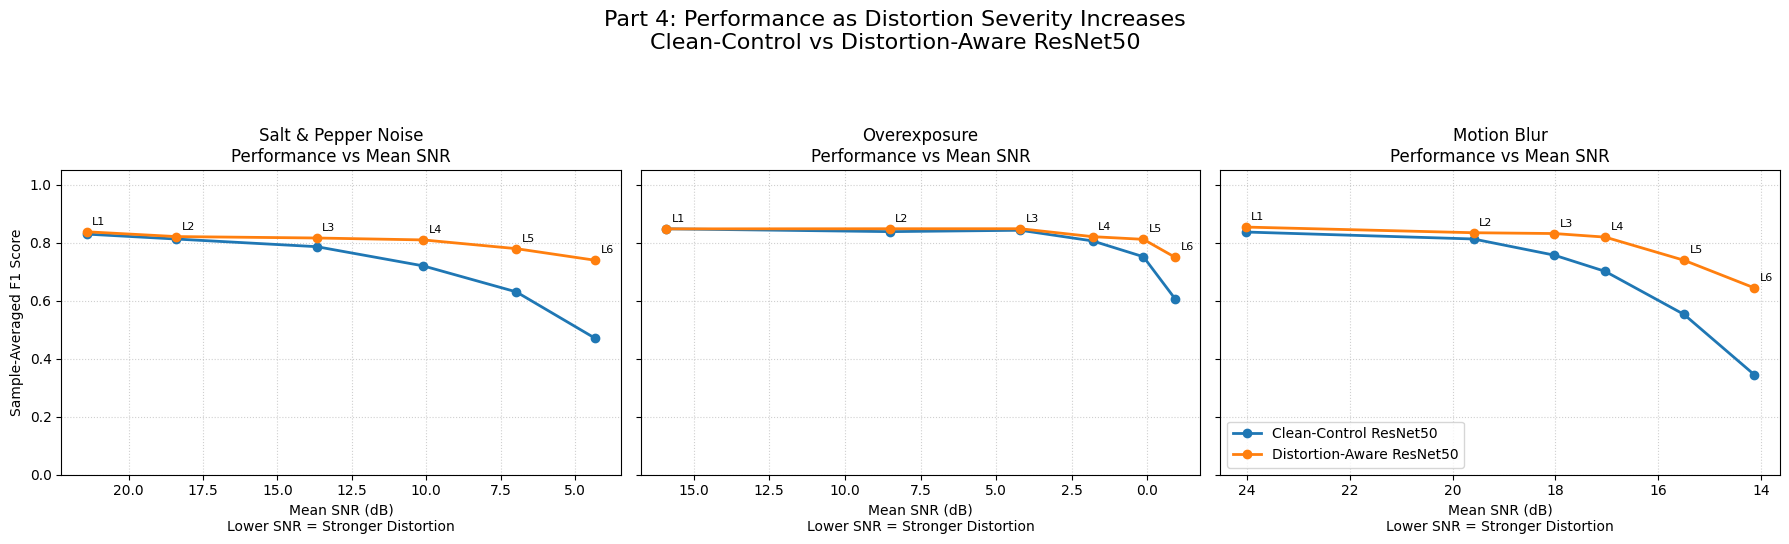


Saved controlled SNR graph to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_finetuning_per_snr.png

Mean performance by model and distortion type:


,model,distortion_type,mean_f1,mean_snr
0,clean_control_resnet50,motion_blur,0.667544,18.048635
1,clean_control_resnet50,overexposure,0.782528,4.943244
2,clean_control_resnet50,salt_pepper,0.708285,12.479828
3,distortion_aware_resnet50,motion_blur,0.787281,18.048635
4,distortion_aware_resnet50,overexposure,0.821316,4.943244
5,distortion_aware_resnet50,salt_pepper,0.800783,12.479828



Cell 7.5 completed successfully.


In [ ]:
# Cell 7.5: Controlled Performance vs SNR
#
# Compare:
# 1. Clean-Control ResNet50
# 2. Distortion-Aware ResNet50
#
# Lower SNR generally represents a stronger distortion.

print("Generating controlled performance vs SNR graphs...")


# ---------------------------------------------------------
# 1. Verify Required Columns
# ---------------------------------------------------------
required_columns = {
    "model",
    "distortion_type",
    "severity_level",
    "mean_snr",
    "f1_samples"
}

missing_columns = required_columns.difference(
    part4_results_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing columns in Part 4 results: "
        f"{sorted(missing_columns)}"
    )


# ---------------------------------------------------------
# 2. Keep Distorted Conditions Only
#
# Clean images are excluded because their SNR is infinite.
# ---------------------------------------------------------
snr_df = part4_results_df[
    part4_results_df["distortion_type"] != "clean"
].copy()


distortion_types = [
    "salt_pepper",
    "overexposure",
    "motion_blur"
]

distortion_titles = {
    "salt_pepper": "Salt & Pepper Noise",
    "overexposure": "Overexposure",
    "motion_blur": "Motion Blur"
}


# ---------------------------------------------------------
# 3. Create the Three SNR Graphs
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharey=True
)


for ax, distortion_type in zip(
    axes,
    distortion_types
):

    subset = snr_df[
        snr_df["distortion_type"] == distortion_type
    ].copy()


    # -----------------------------------------------------
    # Clean-Control Results
    # -----------------------------------------------------
    clean_subset = subset[
        subset["model"] ==
        "clean_control_resnet50"
    ].copy()

    clean_subset = clean_subset.sort_values(
        "severity_level"
    )


    # -----------------------------------------------------
    # Distortion-Aware Results
    # -----------------------------------------------------
    distortion_subset = subset[
        subset["model"] ==
        "distortion_aware_resnet50"
    ].copy()

    distortion_subset = distortion_subset.sort_values(
        "severity_level"
    )


    if clean_subset.empty:
        raise ValueError(
            f"No clean-control results found for "
            f"{distortion_type}."
        )

    if distortion_subset.empty:
        raise ValueError(
            f"No distortion-aware results found for "
            f"{distortion_type}."
        )


    # -----------------------------------------------------
    # Plot Both Models
    # -----------------------------------------------------
    ax.plot(
        clean_subset["mean_snr"],
        clean_subset["f1_samples"],
        marker="o",
        linewidth=2,
        label="Clean-Control ResNet50"
    )

    ax.plot(
        distortion_subset["mean_snr"],
        distortion_subset["f1_samples"],
        marker="o",
        linewidth=2,
        label="Distortion-Aware ResNet50"
    )


    # -----------------------------------------------------
    # Add Severity Labels L1-L6
    # -----------------------------------------------------
    for _, row in distortion_subset.iterrows():

        severity_label = (
            f"L{int(row['severity_level'])}"
        )

        ax.annotate(
            severity_label,
            xy=(
                row["mean_snr"],
                row["f1_samples"]
            ),
            xytext=(4, 5),
            textcoords="offset points",
            fontsize=8
        )


    # -----------------------------------------------------
    # Axis and Title Settings
    # -----------------------------------------------------
    ax.set_title(
        f"{distortion_titles[distortion_type]}\n"
        "Performance vs Mean SNR"
    )

    ax.set_xlabel(
        "Mean SNR (dB)\n"
        "Lower SNR = Stronger Distortion"
    )

    ax.set_ylim(
        0,
        1.05
    )

    ax.grid(
        True,
        linestyle=":",
        alpha=0.6
    )


    # High SNR appears on the left.
    # Moving right represents stronger degradation.
    ax.invert_xaxis()


axes[0].set_ylabel(
    "Sample-Averaged F1 Score"
)

axes[-1].legend(
    loc="lower left"
)


# ---------------------------------------------------------
# 4. Main Figure Title
# ---------------------------------------------------------
fig.suptitle(
    "Part 4: Performance as Distortion Severity Increases\n"
    "Clean-Control vs Distortion-Aware ResNet50",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)


# ---------------------------------------------------------
# 5. Save Figure
# ---------------------------------------------------------
snr_graph_path = (
    FIGURES_DIR /
    "part4_controlled_finetuning_per_snr.png"
)

plt.savefig(
    snr_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print("\nSaved controlled SNR graph to:")
print(snr_graph_path)


# ---------------------------------------------------------
# 6. Numerical Summary by Distortion Type
# ---------------------------------------------------------
snr_summary_df = (
    snr_df
    .groupby(
        [
            "model",
            "distortion_type"
        ],
        as_index=False
    )
    .agg(
        mean_f1=(
            "f1_samples",
            "mean"
        ),
        mean_snr=(
            "mean_snr",
            "mean"
        )
    )
)


print(
    "\nMean performance by model and distortion type:"
)

display(
    snr_summary_df
)

print(
    "\nCell 7.5 completed successfully."
)

Generating controlled qualitative comparison...

Selected validation image: 63
Ground-truth labels: car


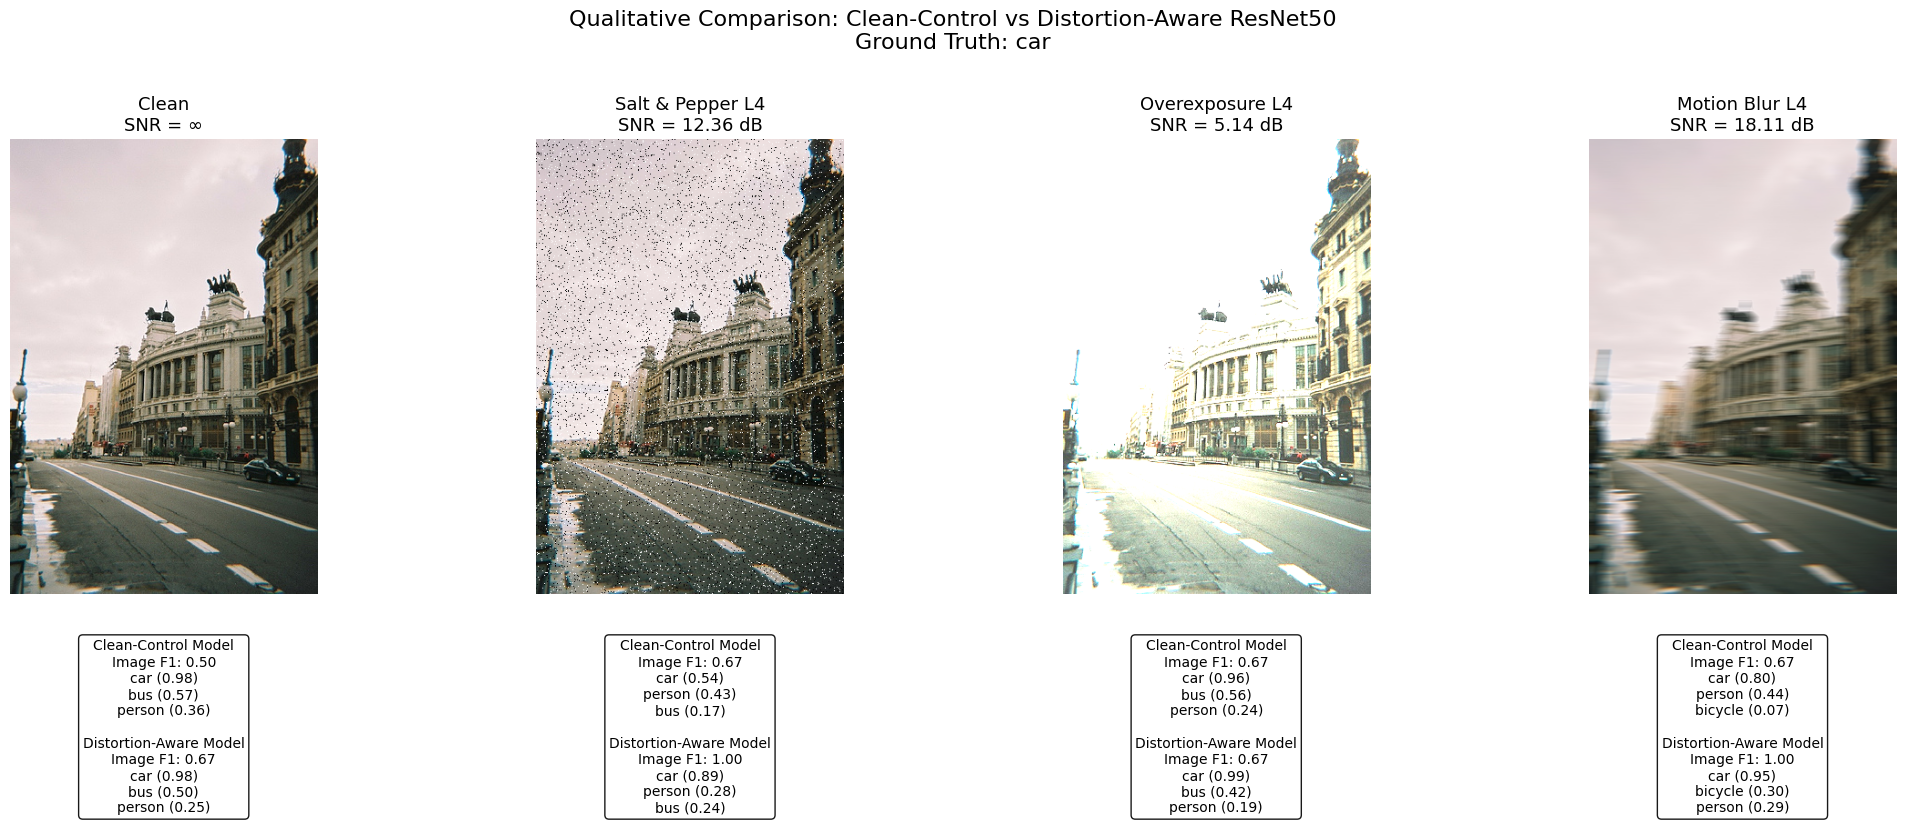


Qualitative example results:


,condition,snr,clean_control_f1,distortion_aware_f1,f1_improvement
0,clean,inf,0.500000,0.666667,0.166667
1,salt_pepper_L4,12.359892,0.666667,1.000000,0.333333
2,overexposure_L4,5.139966,0.666667,0.666667,0.000000
3,motion_blur_L4,18.110518,0.666667,1.000000,0.333333



Saved qualitative graph to:
/content/drive/MyDrive/Digital_image_processing_project/results/figures/part4_controlled_qualitative_comparison.png

Saved qualitative results to:
/content/drive/MyDrive/Digital_image_processing_project/results/tables/part4_controlled_qualitative_example.csv

Cell 8 completed successfully.


In [ ]:
# Cell 8: Controlled Qualitative Prediction Comparison
#
# Visual comparison between:
# 1. Clean-Control ResNet50
# 2. Distortion-Aware ResNet50
#
# The same image is displayed under:
# - Clean condition
# - Salt & Pepper L4
# - Overexposure L4
# - Motion Blur L4

print("Generating controlled qualitative comparison...")
THRESHOLD = 0.3

# ---------------------------------------------------------
# 1. Prediction Function
# ---------------------------------------------------------
def predict_single_image(
    model,
    image_np,
    threshold=0.3,
    top_k=3
):
    model.eval()

    image_pil = Image.fromarray(
        image_np.astype(np.uint8)
    ).convert("RGB")

    image_tensor = transform(
        image_pil
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        logits = model(
            image_tensor
        )

        probabilities = torch.sigmoid(
            logits
        )[0].cpu().numpy()


    binary_prediction = (
        probabilities >= threshold
    ).astype(np.float32)


    top_indices = np.argsort(
        probabilities
    )[::-1][:top_k]


    top_predictions = [
        (
            f"{VOC_CLASSES[index]} "
            f"({probabilities[index]:.2f})"
        )
        for index in top_indices
    ]


    predicted_labels = [
        VOC_CLASSES[index]
        for index, value
        in enumerate(binary_prediction)
        if value == 1
    ]


    return {
        "probabilities": probabilities,
        "binary_prediction": binary_prediction,
        "top_predictions": top_predictions,
        "predicted_labels": predicted_labels
    }


# ---------------------------------------------------------
# 2. Choose Validation Image
#
# Change only vis_idx to display another image.
# Suggested values:
# 5, 10, 15, 25, 35, 50, 80, 120
# ---------------------------------------------------------
vis_idx = 63

if vis_idx < 0 or vis_idx >= len(voc_val):
    raise IndexError(
        f"vis_idx must be between 0 and "
        f"{len(voc_val) - 1}."
    )


image_pil, target = voc_val[
    vis_idx
]

clean_image = np.array(
    image_pil.convert("RGB")
).copy()


ground_truth_vector = target_to_multilabel(
    target
)

ground_truth_labels = [
    VOC_CLASSES[index]
    for index, value
    in enumerate(ground_truth_vector)
    if value == 1
]

ground_truth_text = ", ".join(
    ground_truth_labels
)


print("\nSelected validation image:", vis_idx)

print(
    "Ground-truth labels:",
    ground_truth_text
)


# ---------------------------------------------------------
# 3. Use the Exact Standard L4 Conditions from Cell 2
# ---------------------------------------------------------
condition_names = [
    "clean",
    "salt_pepper_L4",
    "overexposure_L4",
    "motion_blur_L4"
]


configs_to_show = []

for condition_name in condition_names:

    matching_configs = [
        config
        for config in DISTORTION_CONFIGS
        if config["name"] == condition_name
    ]

    if len(matching_configs) != 1:
        raise ValueError(
            f"Could not uniquely find condition: "
            f"{condition_name}"
        )

    configs_to_show.append(
        matching_configs[0]
    )


display_names = {
    "clean": "Clean",
    "salt_pepper_L4": "Salt & Pepper L4",
    "overexposure_L4": "Overexposure L4",
    "motion_blur_L4": "Motion Blur L4"
}


# ---------------------------------------------------------
# 4. Generate Predictions and Plot
# ---------------------------------------------------------
visual_records = []

fig, axes = plt.subplots(
    1,
    len(configs_to_show),
    figsize=(
        5.3 * len(configs_to_show),
        8
    )
)


if len(configs_to_show) == 1:
    axes = [axes]


for column_index, config in enumerate(
    configs_to_show
):

    distorted_image = apply_distortion(
        clean_image,
        config,
        seed=SEED + 200 + vis_idx
    )


    snr_value = compute_snr(
        clean_image,
        distorted_image
    )


    # =====================================================
    # Clean-Control Prediction
    # =====================================================
    clean_control_output = (
        predict_single_image(
            clean_control_model,
            distorted_image,
            threshold=THRESHOLD,
            top_k=3
        )
    )


    # =====================================================
    # Distortion-Aware Prediction
    # =====================================================
    distortion_aware_output = (
        predict_single_image(
            distortion_aware_model,
            distorted_image,
            threshold=0.3,
            top_k=3
        )
    )


    clean_control_f1 = f1_score(
        ground_truth_vector,
        clean_control_output[
            "binary_prediction"
        ],
        zero_division=0
    )


    distortion_aware_f1 = f1_score(
        ground_truth_vector,
        distortion_aware_output[
            "binary_prediction"
        ],
        zero_division=0
    )


    improvement = (
        distortion_aware_f1 -
        clean_control_f1
    )


    # -----------------------------------------------------
    # Store Numerical Results
    # -----------------------------------------------------
    visual_records.append({
        "condition": config["name"],
        "distortion_type": config["type"],
        "severity_level": (
            config["severity_level"]
        ),
        "snr": snr_value,
        "clean_control_f1": (
            clean_control_f1
        ),
        "distortion_aware_f1": (
            distortion_aware_f1
        ),
        "f1_improvement": improvement,
        "ground_truth": ground_truth_text,
        "clean_control_predicted_labels": (
            ", ".join(
                clean_control_output[
                    "predicted_labels"
                ]
            )
        ),
        "distortion_aware_predicted_labels": (
            ", ".join(
                distortion_aware_output[
                    "predicted_labels"
                ]
            )
        )
    })


    # -----------------------------------------------------
    # Display Image
    # -----------------------------------------------------
    axes[column_index].imshow(
        distorted_image
    )

    axes[column_index].axis(
        "off"
    )


    if np.isfinite(snr_value):

        title_text = (
            f"{display_names[config['name']]}\n"
            f"SNR = {snr_value:.2f} dB"
        )

    else:

        title_text = (
            f"{display_names[config['name']]}\n"
            "SNR = ∞"
        )


    axes[column_index].set_title(
        title_text,
        fontsize=13
    )


    # -----------------------------------------------------
    # Prediction Text
    # -----------------------------------------------------
    clean_top3_text = "\n".join(
        clean_control_output[
            "top_predictions"
        ]
    )

    distortion_top3_text = "\n".join(
        distortion_aware_output[
            "top_predictions"
        ]
    )


    prediction_text = (
        "Clean-Control Model\n"
        f"Image F1: {clean_control_f1:.2f}\n"
        f"{clean_top3_text}\n\n"
        "Distortion-Aware Model\n"
        f"Image F1: {distortion_aware_f1:.2f}\n"
        f"{distortion_top3_text}"
    )


    axes[column_index].text(
        0.5,
        -0.10,
        prediction_text,
        transform=(
            axes[column_index].transAxes
        ),
        ha="center",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.9
        }
    )


# ---------------------------------------------------------
# 5. Main Title
# ---------------------------------------------------------
fig.suptitle(
    "Qualitative Comparison: "
    "Clean-Control vs Distortion-Aware ResNet50\n"
    f"Ground Truth: {ground_truth_text}",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.91]
)


# ---------------------------------------------------------
# 6. Save Figure
# ---------------------------------------------------------
qualitative_graph_path = (
    FIGURES_DIR /
    "part4_controlled_qualitative_comparison.png"
)

plt.savefig(
    qualitative_graph_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 7. Save and Display Numerical Results
# ---------------------------------------------------------
qualitative_results_df = pd.DataFrame(
    visual_records
)

qualitative_results_path = (
    TABLES_DIR /
    "part4_controlled_qualitative_example.csv"
)

qualitative_results_df.to_csv(
    qualitative_results_path,
    index=False
)


print("\nQualitative example results:")

display(
    qualitative_results_df[
        [
            "condition",
            "snr",
            "clean_control_f1",
            "distortion_aware_f1",
            "f1_improvement"
        ]
    ]
)


print("\nSaved qualitative graph to:")
print(qualitative_graph_path)

print("\nSaved qualitative results to:")
print(qualitative_results_path)

print("\nCell 8 completed successfully.")


## Part 4: Controlled Fine-Tuning on Distorted Images

In this experiment, two ResNet50 multi-label classification models were initialized from the same clean-trained PASCAL VOC checkpoint.

Both models were trained using identical experimental settings, including the same original image indices, number of samples, number of epochs, trainable layers, optimizer, learning rates, validation images, evaluation threshold, and performance metrics.

The only intentional difference was the type of training input:

* **Clean-Control ResNet50:** additional training on clean images.
* **Distortion-Aware ResNet50:** additional training on distorted images.

The evaluated distortions were Salt & Pepper Noise, Overexposure, and Motion Blur. Each distortion was evaluated at six severity levels, from L1 to L6.

The original PASCAL VOC labels were retained because the distortions changed the visual appearance of the images but did not change the objects present in them.

### Overall Results on Distorted Images

| Model                     | Mean Sample-Averaged F1 |
| ------------------------- | ----------------------: |
| Clean-Control ResNet50    |                  0.7195 |
| Distortion-Aware ResNet50 |                  0.8031 |

The distortion-aware fine-tuning produced an absolute F1 improvement of **+0.0837**, corresponding to a relative improvement of approximately **11.63%**.

### Results per Distortion Type

| Distortion          | Clean-Control F1 | Distortion-Aware F1 | Improvement |
| ------------------- | ---------------: | ------------------: | ----------: |
| Salt & Pepper Noise |           0.7083 |              0.8008 |     +0.0925 |
| Overexposure        |           0.7825 |              0.8213 |     +0.0388 |
| Motion Blur         |           0.6675 |              0.7873 |     +0.1197 |

The largest average improvement was obtained for Motion Blur, followed by Salt & Pepper Noise. The improvement for Overexposure was smaller but remained positive overall.

### Clean-Image Performance

| Model                     | Clean-Image F1 |
| ------------------------- | -------------: |
| Clean-Control ResNet50    |         0.8511 |
| Distortion-Aware ResNet50 |         0.8565 |

The clean-image F1 changed by **+0.0054**. Therefore, the improvement in robustness to distortions did not reduce performance on clean images.

### Strongest Improvement

The largest improvement was observed under **Motion Blur L6**, representing the most severe motion-blur condition.

| Model                     |     F1 |
| ------------------------- | -----: |
| Clean-Control ResNet50    | 0.3442 |
| Distortion-Aware ResNet50 | 0.6441 |

The improvement under this condition was **+0.2999**.

Large improvements were also observed under severe Salt & Pepper Noise:

* Salt & Pepper L6: **0.4698 → 0.7395**
* Improvement: **+0.2697**

Under severe Overexposure:

* Overexposure L6: **0.6074 → 0.7502**
* Improvement: **+0.1428**

### Conclusion

The controlled experiment demonstrates that fine-tuning ResNet50 on distorted images substantially improves its robustness to image degradation.

The distortion-aware model achieved higher performance in almost every evaluated distortion condition. The improvement became especially significant at high distortion severity levels.

The largest benefits were observed for severe Motion Blur and Salt & Pepper Noise. At the same time, performance on clean images was preserved and slightly improved.

These results show that distortion-aware fine-tuning enables the model to generalize better to degraded visual inputs without sacrificing its original clean-image performance.


Generating final fair comparison on 400 images...
Device: cuda
Threshold: 0.3
Images: 400
Batch size: 32

Clean-Control: /content/drive/MyDrive/Digital_image_processing_project/models/resnet50_multilabel_clean_control.pth True
Distortion-Aware: /content/drive/MyDrive/Digital_image_processing_project/models/resnet50_multilabel_distortion_aware.pth True
Both models loaded successfully.

Selected images: 400
First five indices: [1676, 526, 3278, 4933, 4362]
Salt & Pepper L4 {'amount': 0.07}
Overexposure L3 {'factor': 1.6, 'bias': 35}
Motion Blur L4 {'kernel_size': 15}

Computing clean reference...
Clean: 32/400
Clean: 64/400
Clean: 96/400
Clean: 128/400
Clean: 160/400
Clean: 192/400
Clean: 224/400
Clean: 256/400
Clean: 288/400
Clean: 320/400
Clean: 352/400
Clean: 384/400
Clean: 400/400

Condition 1/3: Salt & Pepper L4
Salt & Pepper L4: 32/400
Salt & Pepper L4: 64/400
Salt & Pepper L4: 96/400
Salt & Pepper L4: 128/400
Salt & Pepper L4: 160/400
Salt & Pepper L4: 192/400
Salt & Pepper L4: 22

,condition,evaluation_images,distorted_clean_control_f1,restored_clean_control_f1,distorted_distortion_aware_f1,restoration_improvement,finetuning_improvement
0,Salt & Pepper L4,400,0.720131,0.805458,0.809815,0.085327,0.089685
1,Overexposure L3,400,0.843107,0.828881,0.848435,-0.014226,0.005327
2,Motion Blur L4,400,0.701202,0.709036,0.819490,0.007833,0.118288


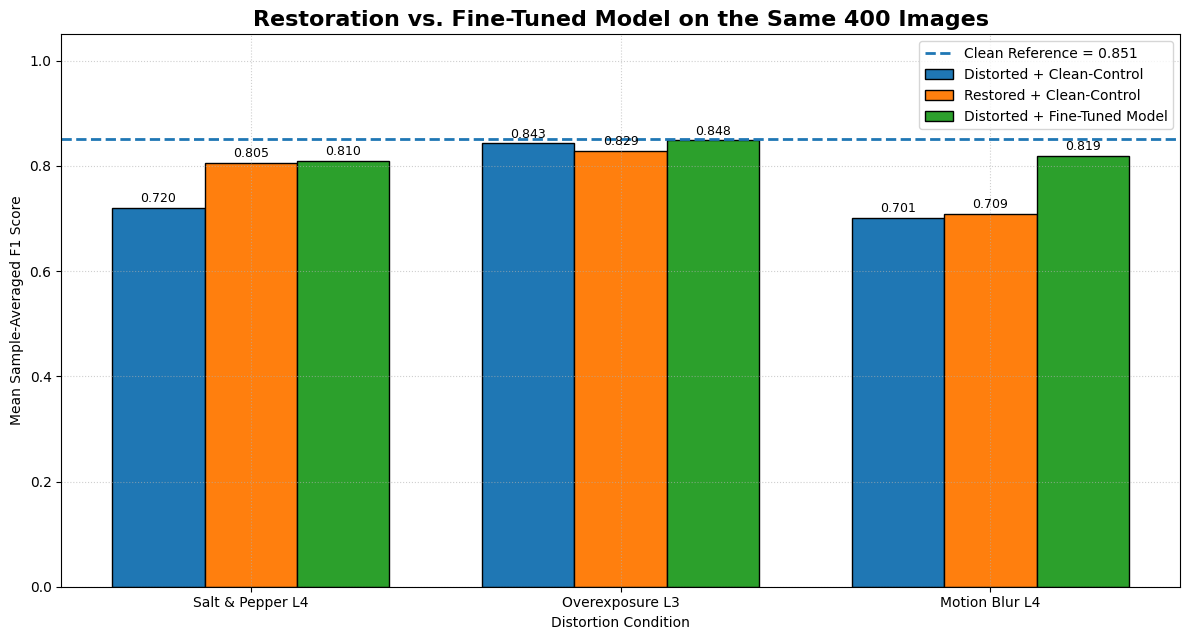


Saved detailed CSV: /content/drive/MyDrive/Digital_image_processing_project/results/tables/final_dl_comparison_same_400_images_detailed.csv
Saved summary CSV: /content/drive/MyDrive/Digital_image_processing_project/results/tables/final_dl_comparison_same_400_images_summary.csv
Saved graph: /content/drive/MyDrive/Digital_image_processing_project/results/figures/final_dl_restoration_vs_finetuning_same_400_images.png

Completed successfully.


In [ ]:
# Final Deep-Learning Comparison on the Same 400 Images
# 1. Distorted -> Clean-Control
# 2. Restored  -> Clean-Control
# 3. Distorted -> Distortion-Aware
# Evaluation only: no model training is performed here.

print("Generating final fair comparison on 400 images...")

import cv2
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score

# ---------------------------------------------------------
# Settings and required objects from Cells 1-2
# ---------------------------------------------------------
required = [
    "SEED", "device", "voc_val", "VOC_CLASSES", "MODELS_DIR",
    "TABLES_DIR", "FIGURES_DIR", "target_to_multilabel",
    "DISTORTION_CONFIGS", "apply_distortion"
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        f"Missing objects: {missing}\nRun Cell 1 and Cell 2 first."
    )

THRESHOLD = 0.30
NUM_IMAGES = 400
EVAL_SEED = SEED + 200
BATCH_SIZE_FINAL = 32 if device.type == "cuda" else 8
transform = ResNet50_Weights.DEFAULT.transforms()

print("Device:", device)
print("Threshold:", THRESHOLD)
print("Images:", NUM_IMAGES)
print("Batch size:", BATCH_SIZE_FINAL)

# ---------------------------------------------------------
# Load the two saved controlled models
# ---------------------------------------------------------
def build_model():
    model = resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(VOC_CLASSES))
    return model


def load_model(path):
    if not path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n{path}\n"
            "The saved models from Cell 5 are required."
        )
    model = build_model()
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)
    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad = False
    return model


clean_control_path = MODELS_DIR / "resnet50_multilabel_clean_control.pth"
distortion_aware_path = MODELS_DIR / "resnet50_multilabel_distortion_aware.pth"

print("\nClean-Control:", clean_control_path, clean_control_path.exists())
print("Distortion-Aware:", distortion_aware_path, distortion_aware_path.exists())

clean_control_model = load_model(clean_control_path)
distortion_aware_model = load_model(distortion_aware_path)
print("Both models loaded successfully.")

# ---------------------------------------------------------
# Exact same 400 indices used in the main evaluation
# ---------------------------------------------------------
eval_indices_400 = list(range(len(voc_val)))
rng = random.Random(EVAL_SEED)
rng.shuffle(eval_indices_400)
eval_indices_400 = eval_indices_400[:NUM_IMAGES]

if len(eval_indices_400) != NUM_IMAGES:
    raise ValueError(f"Expected {NUM_IMAGES} images, found {len(eval_indices_400)}.")

print("\nSelected images:", len(eval_indices_400))
print("First five indices:", eval_indices_400[:5])

# ---------------------------------------------------------
# Same representative conditions used in restoration
# ---------------------------------------------------------
requested_conditions = [
    ("salt_pepper", 4, "Salt & Pepper L4"),
    ("overexposure", 3, "Overexposure L3"),
    ("motion_blur", 4, "Motion Blur L4")
]

conditions = []
for distortion_type, level, label in requested_conditions:
    config = next(
        config for config in DISTORTION_CONFIGS
        if config["type"] == distortion_type
        and config["severity_level"] == level
    )
    conditions.append((config, label))
    print(label, config["params"])

# ---------------------------------------------------------
# Restoration functions
# ---------------------------------------------------------
def restore_motion_blur(image, kernel_size):
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    kernel[kernel_size // 2, :] = 1.0 / kernel_size
    flipped_kernel = cv2.flip(kernel, -1)

    observed_rgb = image.astype(np.float32) / 255.0
    epsilon = 1e-6
    restored_channels = []

    for channel_index in range(3):
        observed = observed_rgb[:, :, channel_index]
        estimate = np.clip(observed.copy(), epsilon, 1.0)

        for _ in range(8):
            blurred_estimate = cv2.filter2D(
                estimate, -1, kernel, borderType=cv2.BORDER_REPLICATE
            )
            ratio = observed / (blurred_estimate + epsilon)
            correction = cv2.filter2D(
                ratio, -1, flipped_kernel, borderType=cv2.BORDER_REPLICATE
            )
            estimate = np.clip(estimate * correction, 0.0, 1.0)

        restored_channels.append(estimate)

    deblurred = np.stack(restored_channels, axis=2)
    deblurred = (np.clip(deblurred, 0.0, 1.0) * 255).astype(np.uint8)
    deblurred = cv2.bilateralFilter(deblurred, 5, 25, 25)

    restored = cv2.addWeighted(image, 0.45, deblurred, 0.55, 0)

    lab = cv2.cvtColor(restored, cv2.COLOR_RGB2LAB)
    luminance, a_channel, b_channel = cv2.split(lab)
    blurred_luminance = cv2.GaussianBlur(luminance, (0, 0), sigmaX=1.0)
    sharpened_luminance = cv2.addWeighted(
        luminance, 1.25, blurred_luminance, -0.25, 0
    )
    restored_lab = cv2.merge((
        sharpened_luminance.astype(np.uint8),
        a_channel,
        b_channel
    ))
    return cv2.cvtColor(restored_lab, cv2.COLOR_LAB2RGB)


def restore_image(image, config):
    distortion_type = config["type"]
    params = config["params"]

    if distortion_type == "salt_pepper":
        return cv2.medianBlur(image, 5)

    if distortion_type == "overexposure":
        recovered = (
            image.astype(np.float32) - params["bias"]
        ) / params["factor"]
        recovered = np.clip(recovered, 0, 255).astype(np.uint8)

        lab = cv2.cvtColor(recovered, cv2.COLOR_RGB2LAB)
        luminance, a_channel, b_channel = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
        clahe_luminance = clahe.apply(luminance)
        blended = cv2.addWeighted(luminance, 0.75, clahe_luminance, 0.25, 0)
        restored_lab = cv2.merge((blended, a_channel, b_channel))
        return cv2.cvtColor(restored_lab, cv2.COLOR_LAB2RGB)

    if distortion_type == "motion_blur":
        return restore_motion_blur(image, params["kernel_size"])

    return image.copy()

# ---------------------------------------------------------
# Prediction helpers
# ---------------------------------------------------------
def predict_batch(model, images):
    tensors = torch.stack([
        transform(Image.fromarray(image.astype(np.uint8)).convert("RGB"))
        for image in images
    ]).to(device)

    with torch.no_grad():
        probabilities = torch.sigmoid(model(tensors)).cpu().numpy()

    return (probabilities >= THRESHOLD).astype(np.float32)


def per_image_f1(y_true, y_pred):
    return np.array([
        f1_score(true_row, pred_row, zero_division=0)
        for true_row, pred_row in zip(y_true, y_pred)
    ], dtype=np.float32)

# ---------------------------------------------------------
# Clean reference, calculated once
# ---------------------------------------------------------
clean_f1_by_index = {}
print("\nComputing clean reference...")

for start in range(0, NUM_IMAGES, BATCH_SIZE_FINAL):
    batch_indices = eval_indices_400[start:start + BATCH_SIZE_FINAL]
    images, labels = [], []

    for sample_index in batch_indices:
        image_pil, target = voc_val[sample_index]
        images.append(np.array(image_pil.convert("RGB")).copy())
        labels.append(target_to_multilabel(target))

    labels = np.stack(labels)
    predictions = predict_batch(clean_control_model, images)
    scores = per_image_f1(labels, predictions)

    for sample_index, score in zip(batch_indices, scores):
        clean_f1_by_index[sample_index] = float(score)

    print(f"Clean: {min(start + len(batch_indices), NUM_IMAGES)}/{NUM_IMAGES}")

# ---------------------------------------------------------
# Three-way comparison
# ---------------------------------------------------------
records = []

for condition_number, (config, condition_name) in enumerate(conditions, start=1):
    print("\n" + "=" * 65)
    print(f"Condition {condition_number}/3: {condition_name}")
    print("=" * 65)

    for start in range(0, NUM_IMAGES, BATCH_SIZE_FINAL):
        batch_indices = eval_indices_400[start:start + BATCH_SIZE_FINAL]
        distorted_images, restored_images, labels = [], [], []

        for sample_index in batch_indices:
            image_pil, target = voc_val[sample_index]
            clean_image = np.array(image_pil.convert("RGB")).copy()
            labels.append(target_to_multilabel(target))

            distorted = apply_distortion(
                clean_image,
                config,
                seed=EVAL_SEED + sample_index
            )
            restored = restore_image(distorted, config)

            distorted_images.append(distorted)
            restored_images.append(restored)

        labels = np.stack(labels)

        distorted_clean_pred = predict_batch(clean_control_model, distorted_images)
        restored_clean_pred = predict_batch(clean_control_model, restored_images)
        distorted_aware_pred = predict_batch(distortion_aware_model, distorted_images)

        distorted_clean_f1 = per_image_f1(labels, distorted_clean_pred)
        restored_clean_f1 = per_image_f1(labels, restored_clean_pred)
        distorted_aware_f1 = per_image_f1(labels, distorted_aware_pred)

        for row, sample_index in enumerate(batch_indices):
            records.append({
                "sample_index": sample_index,
                "condition": condition_name,
                "distortion_type": config["type"],
                "severity_level": config["severity_level"],
                "clean_reference_f1": clean_f1_by_index[sample_index],
                "distorted_clean_control_f1": float(distorted_clean_f1[row]),
                "restored_clean_control_f1": float(restored_clean_f1[row]),
                "distorted_distortion_aware_f1": float(distorted_aware_f1[row])
            })

        print(
            f"{condition_name}: "
            f"{min(start + len(batch_indices), NUM_IMAGES)}/{NUM_IMAGES}"
        )

        if device.type == "cuda":
            torch.cuda.empty_cache()

# ---------------------------------------------------------
# Summary and saved files
# ---------------------------------------------------------
detailed_df = pd.DataFrame(records)

summary_df = (
    detailed_df
    .groupby(
        ["distortion_type", "condition", "severity_level"],
        as_index=False
    )
    .agg(
        evaluation_images=("sample_index", "nunique"),
        clean_reference_f1=("clean_reference_f1", "mean"),
        distorted_clean_control_f1=("distorted_clean_control_f1", "mean"),
        restored_clean_control_f1=("restored_clean_control_f1", "mean"),
        distorted_distortion_aware_f1=(
            "distorted_distortion_aware_f1", "mean"
        )
    )
)

summary_df["restoration_improvement"] = (
    summary_df["restored_clean_control_f1"] -
    summary_df["distorted_clean_control_f1"]
)
summary_df["finetuning_improvement"] = (
    summary_df["distorted_distortion_aware_f1"] -
    summary_df["distorted_clean_control_f1"]
)

order = {"salt_pepper": 0, "overexposure": 1, "motion_blur": 2}
summary_df["order"] = summary_df["distortion_type"].map(order)
summary_df = summary_df.sort_values("order").drop(columns="order").reset_index(drop=True)

detailed_path = TABLES_DIR / "final_dl_comparison_same_400_images_detailed.csv"
summary_path = TABLES_DIR / "final_dl_comparison_same_400_images_summary.csv"
detailed_df.to_csv(detailed_path, index=False)
summary_df.to_csv(summary_path, index=False)

columns_to_show = [
    "condition",
    "evaluation_images",
    "distorted_clean_control_f1",
    "restored_clean_control_f1",
    "distorted_distortion_aware_f1",
    "restoration_improvement",
    "finetuning_improvement"
]

print("\nFinal comparison results:")
try:
    display(summary_df[columns_to_show])
except NameError:
    print(summary_df[columns_to_show].to_string(index=False))

# ---------------------------------------------------------
# Graph
# ---------------------------------------------------------
x = np.arange(len(summary_df))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6.5))

bars_1 = ax.bar(
    x - width,
    summary_df["distorted_clean_control_f1"],
    width,
    label="Distorted + Clean-Control",
    edgecolor="black"
)
bars_2 = ax.bar(
    x,
    summary_df["restored_clean_control_f1"],
    width,
    label="Restored + Clean-Control",
    edgecolor="black"
)
bars_3 = ax.bar(
    x + width,
    summary_df["distorted_distortion_aware_f1"],
    width,
    label="Distorted + Fine-Tuned Model",
    edgecolor="black"
)

clean_mean = float(detailed_df["clean_reference_f1"].mean())
ax.axhline(
    clean_mean,
    linestyle="--",
    linewidth=2,
    label=f"Clean Reference = {clean_mean:.3f}"
)

for bars in [bars_1, bars_2, bars_3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            (bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(summary_df["condition"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Distortion Condition")
ax.set_ylabel("Mean Sample-Averaged F1 Score")
ax.set_title(
    "Restoration vs. Fine-Tuned Model on the Same 400 Images",
    fontsize=16,
    fontweight="bold"
)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

graph_path = FIGURES_DIR / "final_dl_restoration_vs_finetuning_same_400_images.png"
plt.savefig(graph_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved detailed CSV:", detailed_path)
print("Saved summary CSV:", summary_path)
print("Saved graph:", graph_path)
print("\nCompleted successfully.")